### Research Question & setup
In this project, I want to determine which symptom is the best indicator for distinguishing between a normal cough caused by a cold and a cough caused by COVID-19.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import json
import glob
import re
import os
import warnings
import librosa
import shap
from tqdm import tqdm
from scipy.signal import butter, lfilter, sosfiltfilt, hilbert, welch
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, roc_auc_score, confusion_matrix, silhouette_score, adjusted_rand_score,
    silhouette_samples, homogeneity_score, v_measure_score, completeness_score, normalized_mutual_info_score    
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import tensorflow as tf

# Suppress all deprecation warnings
warnings.filterwarnings("ignore", category=FutureWarning)

#### Import csv data & Filtering
filter data based off cough_detected and existence of expert label

In [4]:
work_dir = os.getcwd()
csv_path = f"{work_dir}/metadata_compiled.csv"
audio_path1 = f"{work_dir}/../coughvid_20211012"
audio_path2 = f"D:/uniDev/coughvid_20211012"
#audio_path = f"{work_dir}/../08_coughvid"


audio_path = audio_path1 if os.path.exists(audio_path1) else audio_path2
all_files = os.listdir(audio_path)

# load csv
df = pd.read_csv(csv_path, index_col=0)
print(f"total datapoints in csv: {len(df)}")

# filter for cough_detected
df_clean = df[df['cough_detected'] >= 0.8].copy()
print(f"datapoints with cough_detected (>= 0.8): {len(df_clean)}")

# extract expert labelled datapoints
expert_cols = [col for col in df_clean.columns if any(f'_{i}' in col for i in range(1, 5))]
df_expert = df_clean[df_clean[expert_cols].notna().any(axis=1)].copy()
print(f"datapoints with expert labels: {len(df_expert)}")

total datapoints in csv: 34434
datapoints with cough_detected (>= 0.8): 18544
datapoints with expert labels: 2481


### Data exploration

#### Metadata Analysis

In [5]:
df.head()
#df_expert.head()

,uuid,datetime,cough_detected,latitude,longitude,age,gender,respiratory_condition,fever_muscle_pain,status,...,quality_4,cough_type_4,dyspnea_4,wheezing_4,stridor_4,choking_4,congestion_4,nothing_4,diagnosis_4,severity_4
0,00014dcc-0f06-4c27-8c7b-737b18a2cf4c,2020-11-25T18:58:50.488301+00:00,0.0155,48.9,2.4,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00039425-7f3a-42aa-ac13-834aaa2b6b92,2020-04-13T21:30:59.801831+00:00,0.9609,31.3,34.8,15.0,male,False,False,healthy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0007c6f1-5441-40e6-9aaf-a761d8f2da3b,2020-10-18T15:38:38.205870+00:00,0.1643,NaN,NaN,46.0,female,False,False,healthy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00098cdb-4da1-4aa7-825a-4f1b9abc214b,2021-01-22T22:08:06.742577+00:00,0.1133,47.4,9.4,66.0,female,False,False,healthy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0009eb28-d8be-4dc1-92bb-907e53bc5c7a,2020-04-12T04:02:18.159383+00:00,0.9301,40.0,-75.1,34.0,male,True,False,healthy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### Completeness of all column

In [6]:
# Calculate number of NaN values per column
nan_counts = df_clean.isna().sum().to_frame(name='NaN Count')

# Calculate percentage of NaN values
nan_counts['Percentage'] = (nan_counts['NaN Count'] / len(df_clean) * 100).round(2)

# Sort by NaN count descending
nan_counts = nan_counts.sort_values(by='NaN Count', ascending=False)

print("--- Missing Values (NaN) per Column ---")
print(nan_counts)

--- Missing Values (NaN) per Column ---
                       NaN Count  Percentage
diagnosis_3                17889       96.47
severity_3                 17889       96.47
cough_type_3               17889       96.47
quality_3                  17881       96.42
wheezing_3                 17881       96.42
stridor_3                  17881       96.42
choking_3                  17881       96.42
dyspnea_3                  17881       96.42
congestion_3               17881       96.42
nothing_3                  17881       96.42
diagnosis_1                17876       96.40
wheezing_1                 17876       96.40
dyspnea_1                  17876       96.40
cough_type_1               17876       96.40
stridor_1                  17876       96.40
quality_1                  17876       96.40
choking_1                  17876       96.40
congestion_1               17876       96.40
nothing_1                  17876       96.40
severity_1                 17876       96.40
cough_type_2   

status_SSL is missing roughly 50% of the time and we have no deeper explanation on how it was created, therefore it can be dsicarded later on

##### Data distribution

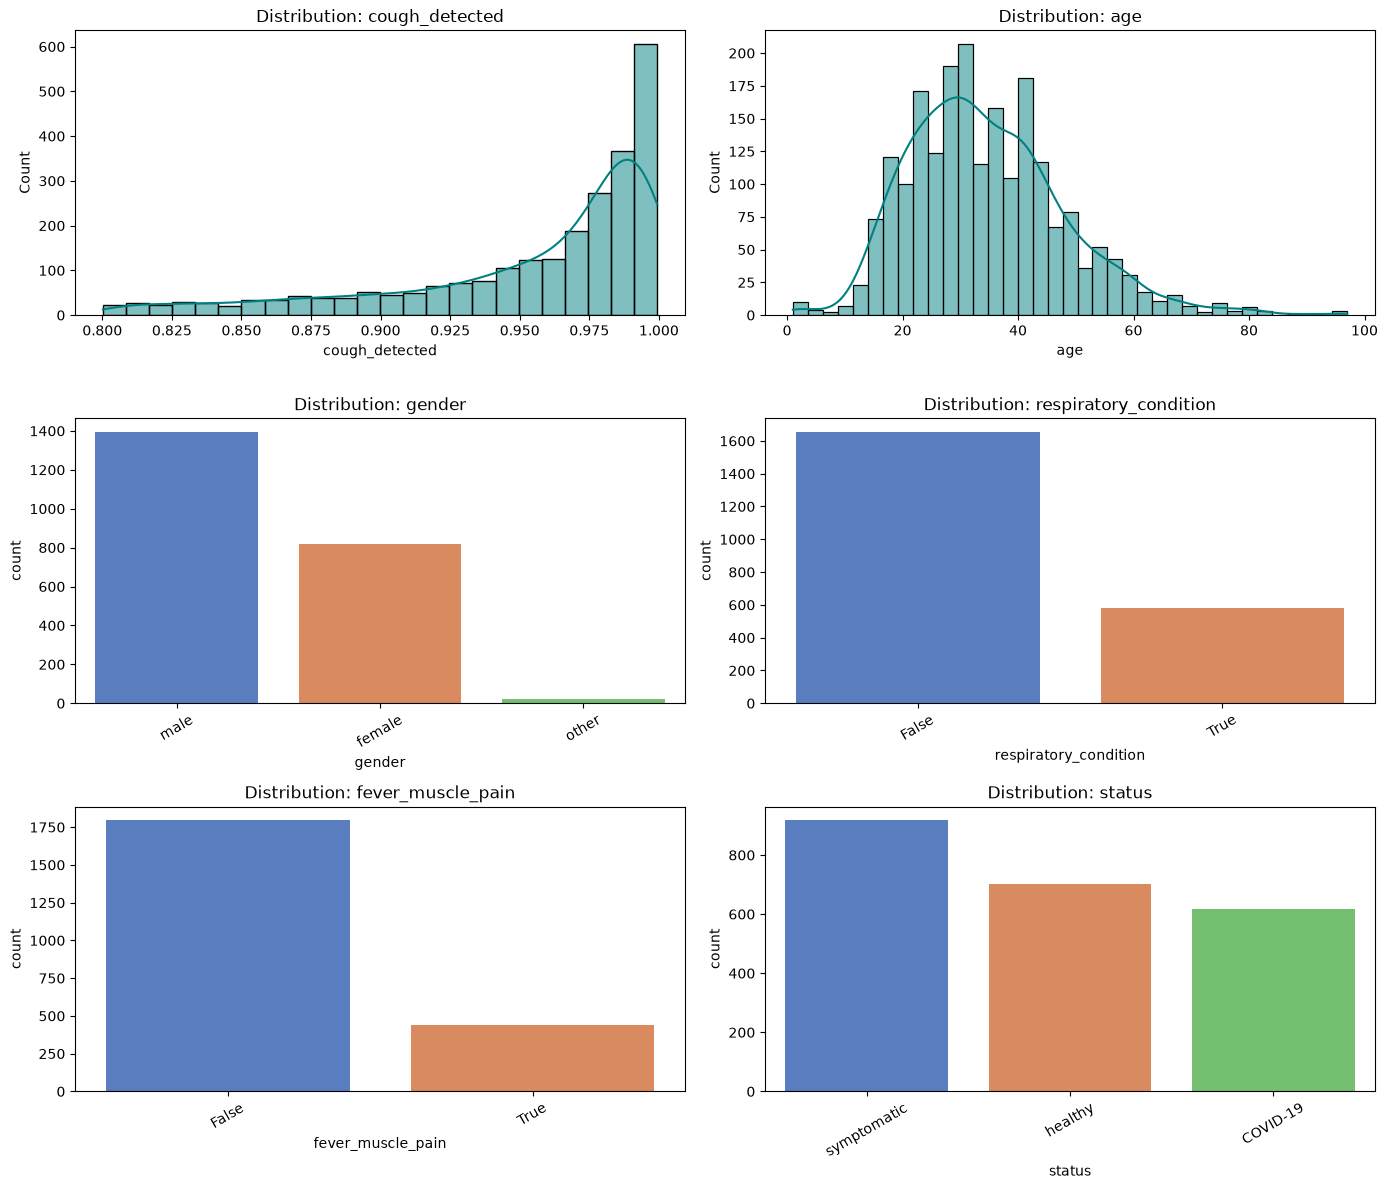

In [7]:
# 1. Identify columns to exclude
# We exclude status_SSL and anything ending in _1, _2, _3, or _4
regex_expert = r'(_[1-4])$'
cols_to_plot = [c for c in df_expert.columns 
                if not re.search(regex_expert, c) 
                and c not in ['status_SSL', 'uuid', 'datetime', 'latitude', 'longitude']]

# 2. Setup plotting grid
n_cols = 2
n_rows = (len(cols_to_plot) + 1) // n_cols
plt.figure(figsize=(14, 4 * n_rows))

for i, col in enumerate(cols_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Drop NaNs for plotting
    data_subset = df_expert[col].dropna()
    
    if data_subset.empty:
        plt.text(0.5, 0.5, f'No data for {col}', ha='center')
        continue

    # Determine plot type based on data type
    if df_expert[col].dtype in ['float64', 'int64']:
        # Numerical Distribution
        sns.histplot(data_subset, kde=True, color='teal')
        plt.title(f'Distribution: {col}')
    else:
        # Categorical Distribution
        # Use value_counts to handle booleans and strings nicely
        order = data_subset.value_counts().index
        sns.countplot(x=data_subset, order=order, palette='muted')
        plt.xticks(rotation=30)
        plt.title(f'Distribution: {col}')

plt.tight_layout()
plt.show()

##### Age distribution

status
healthy        10132
symptomatic     2683
COVID-19         720
Name: count, dtype: int64


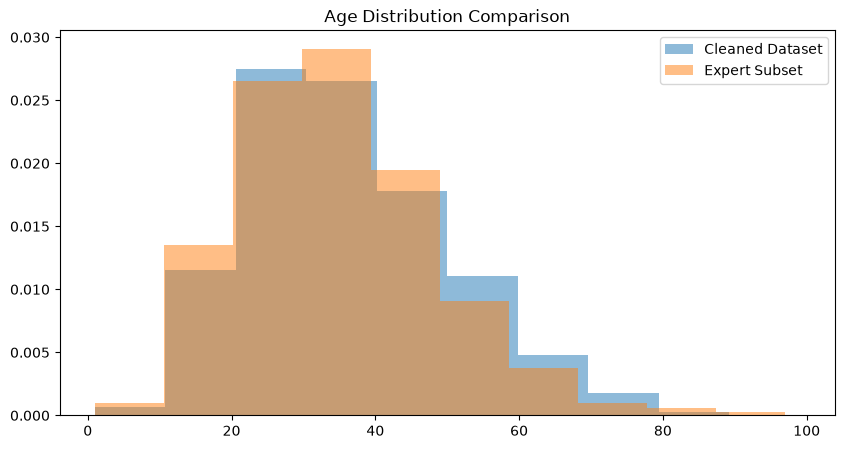

In [8]:
# overview of the full cleaned dataset
print(df_clean['status'].value_counts()) 

plt.figure(figsize=(10, 5))
plt.hist(df_clean['age'].dropna(), alpha=0.5, label='Cleaned Dataset', density=True)
plt.hist(df_expert['age'].dropna(), alpha=0.5, label='Expert Subset', density=True)
plt.title('Age Distribution Comparison')
plt.legend()
plt.show()

##### expert labeled distributions

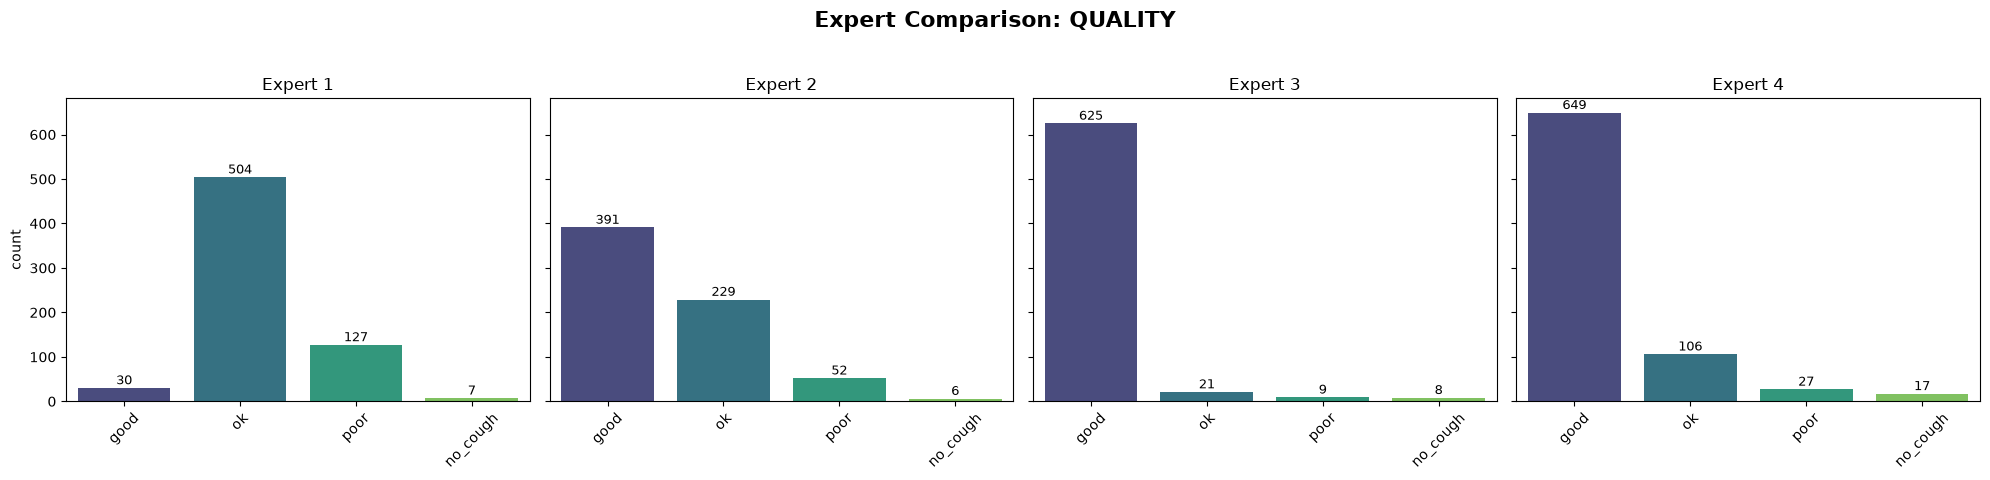

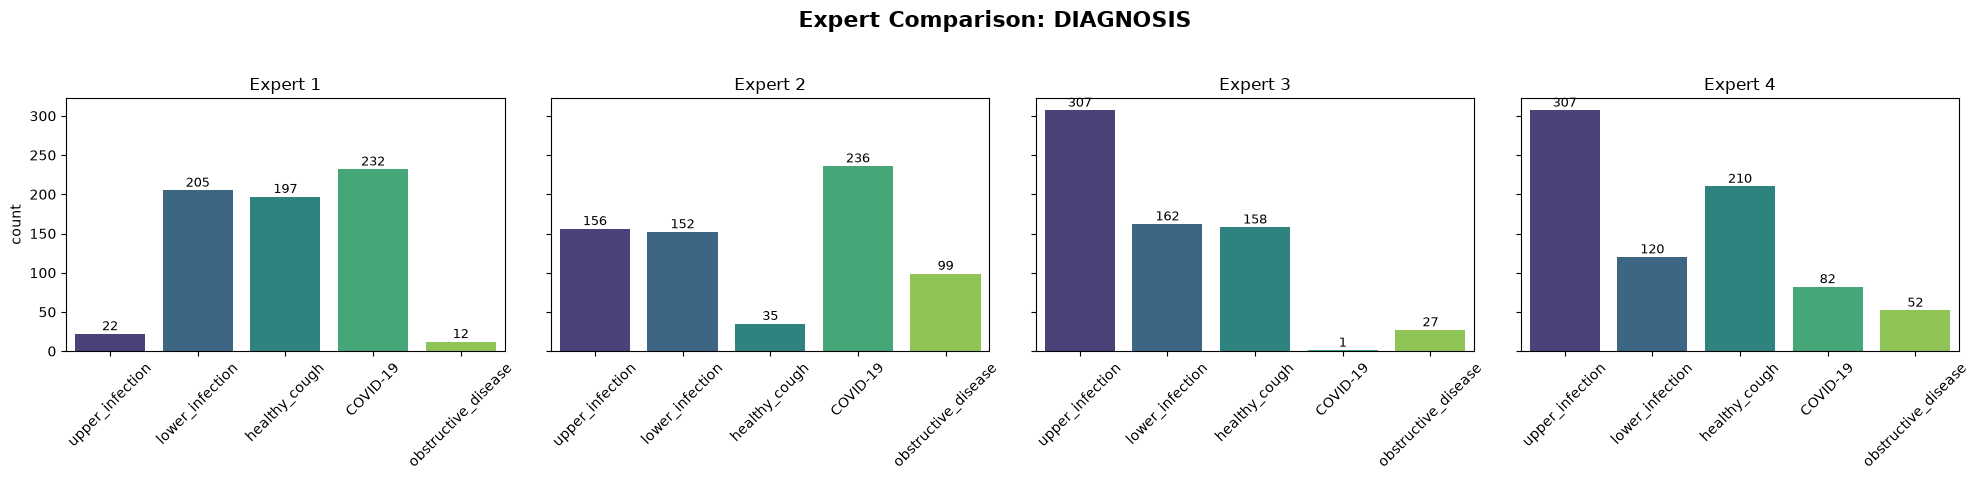

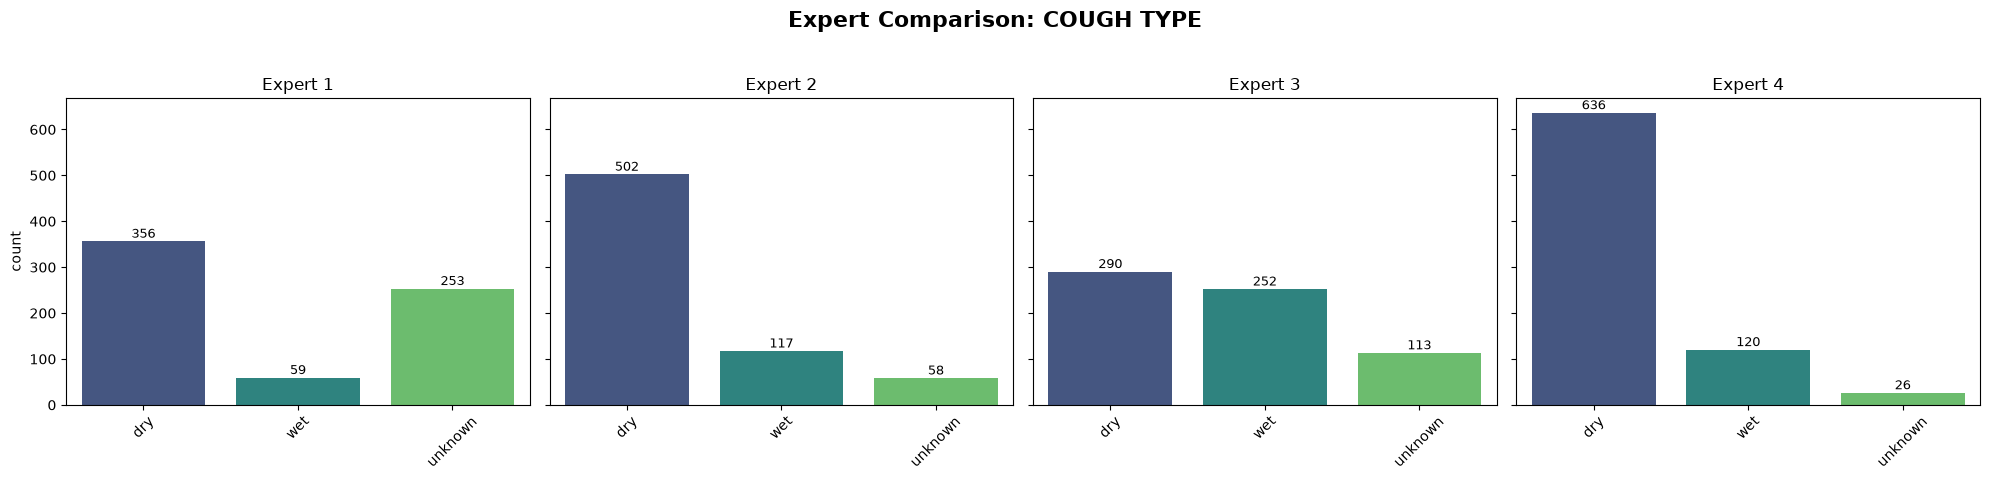

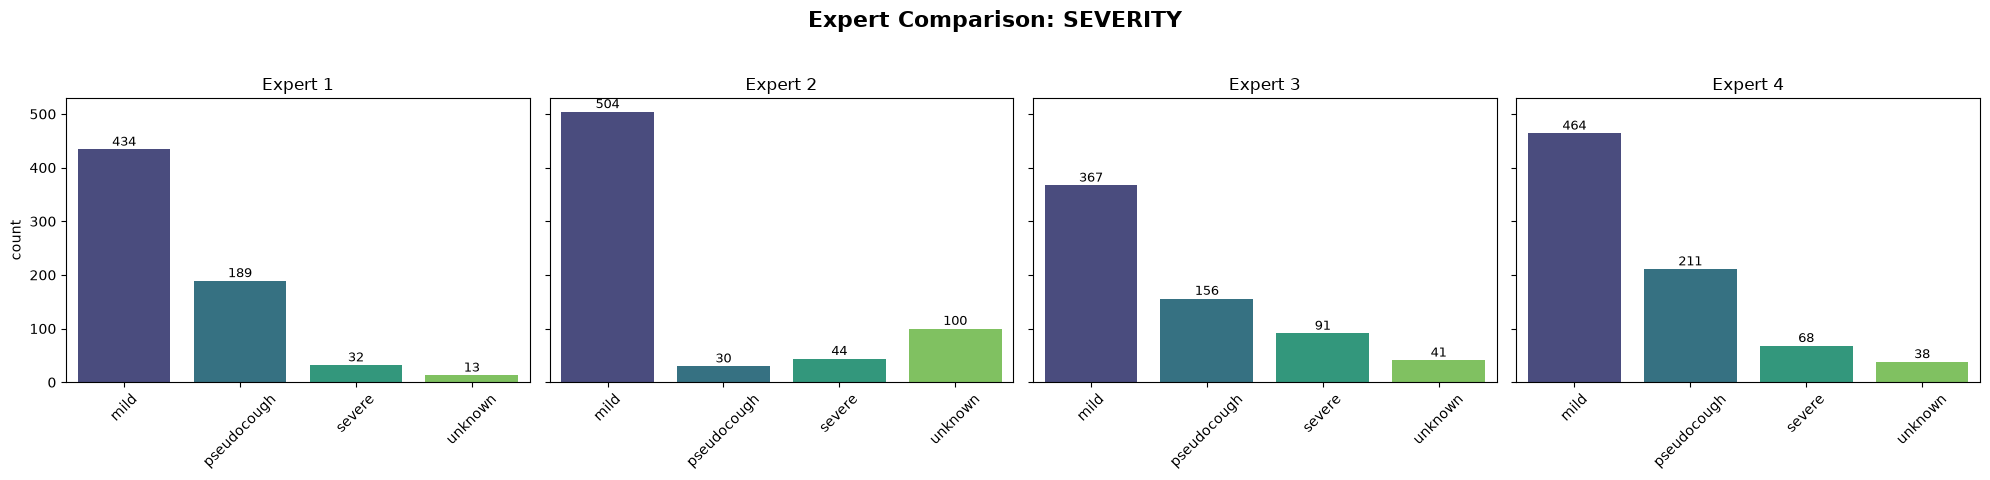

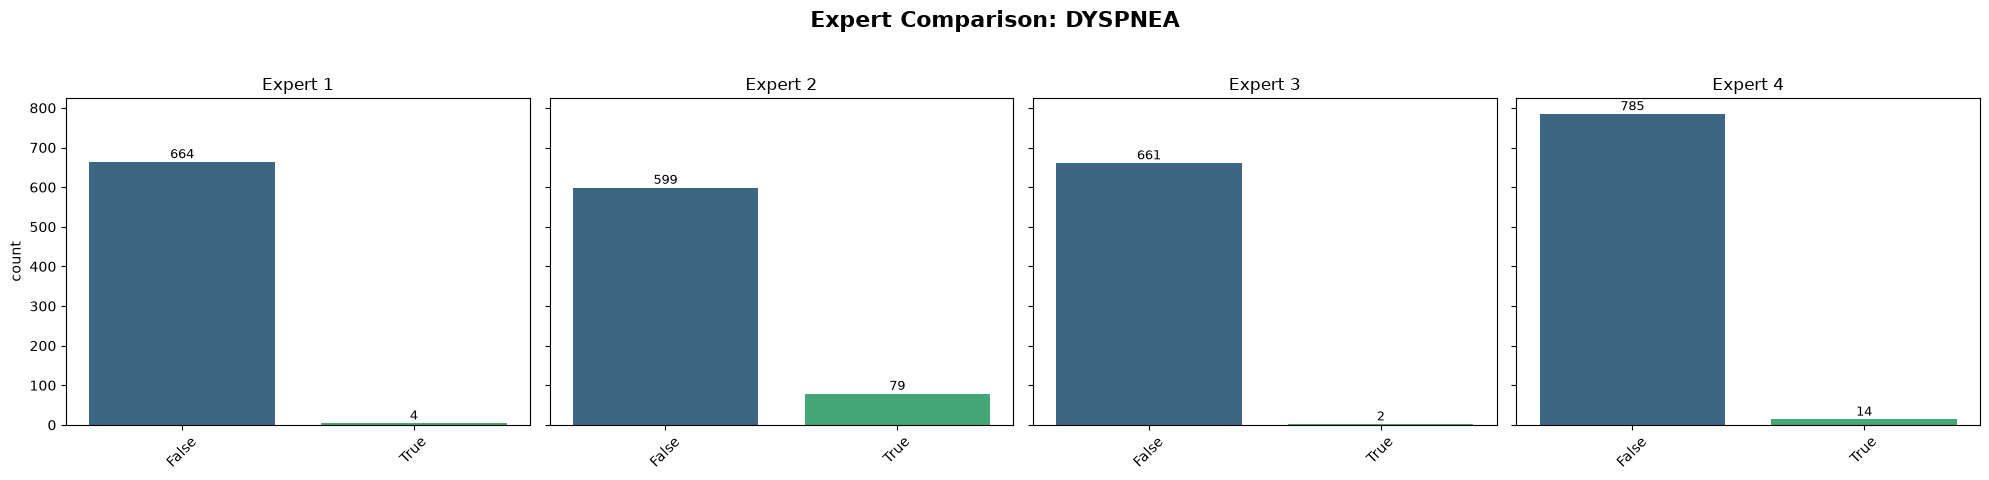

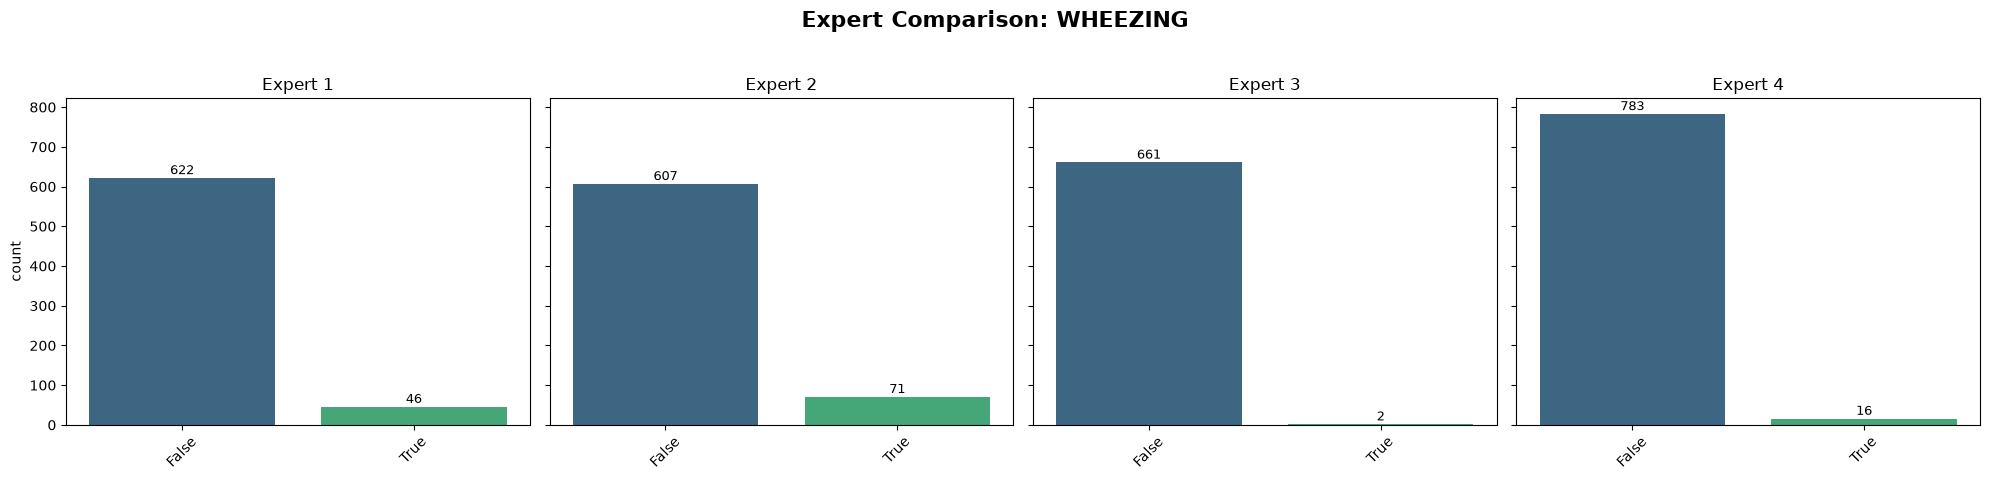

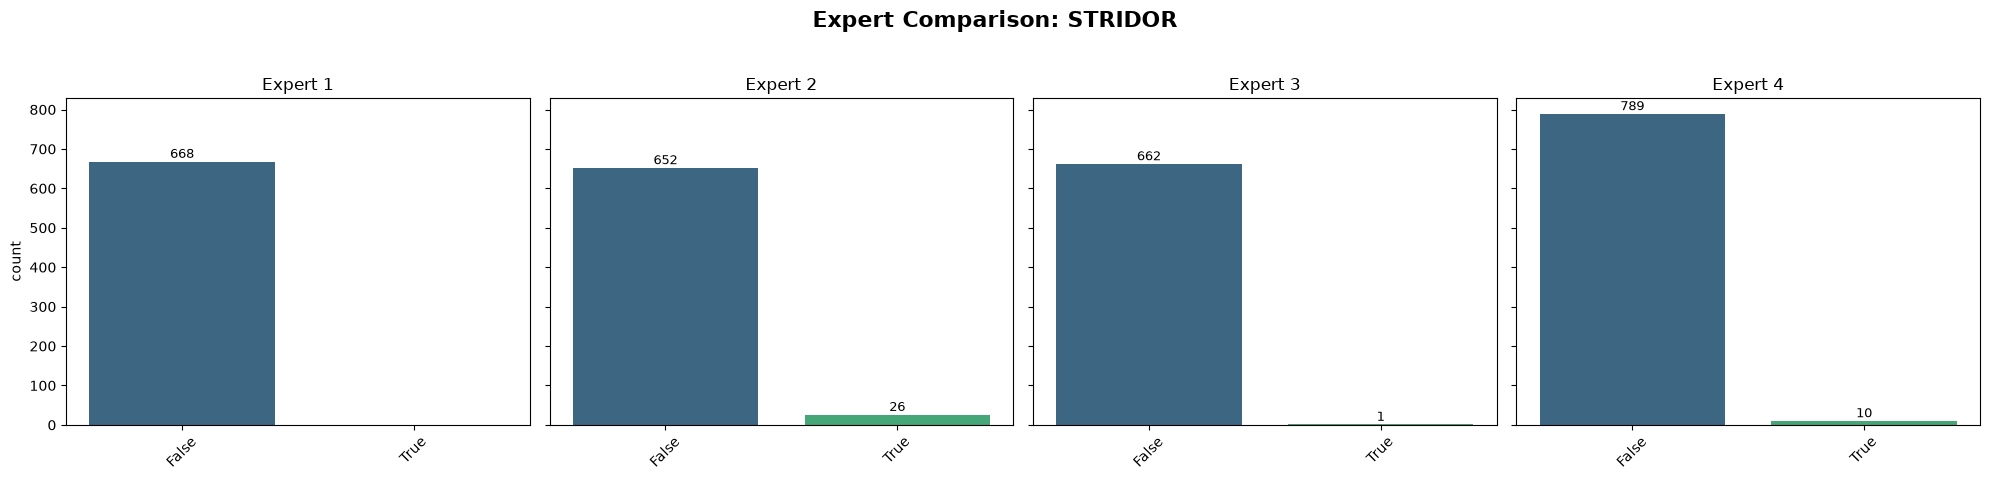

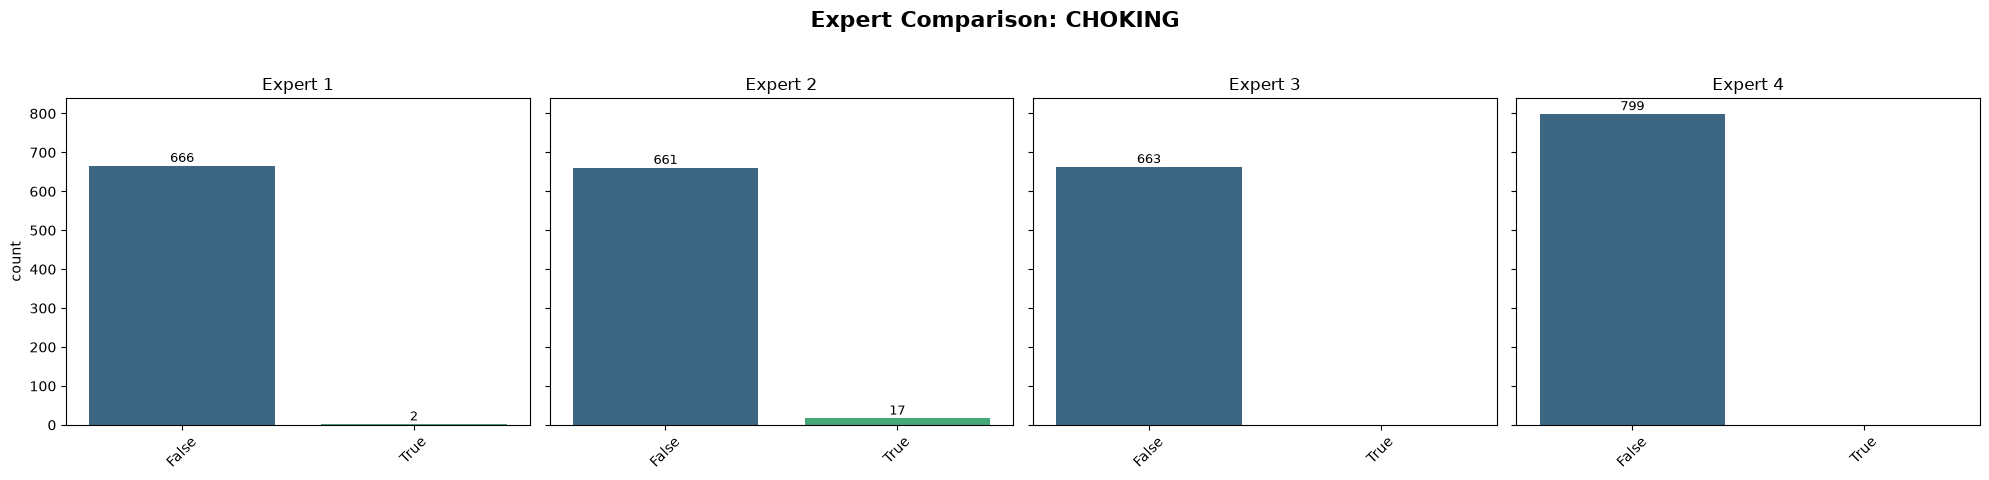

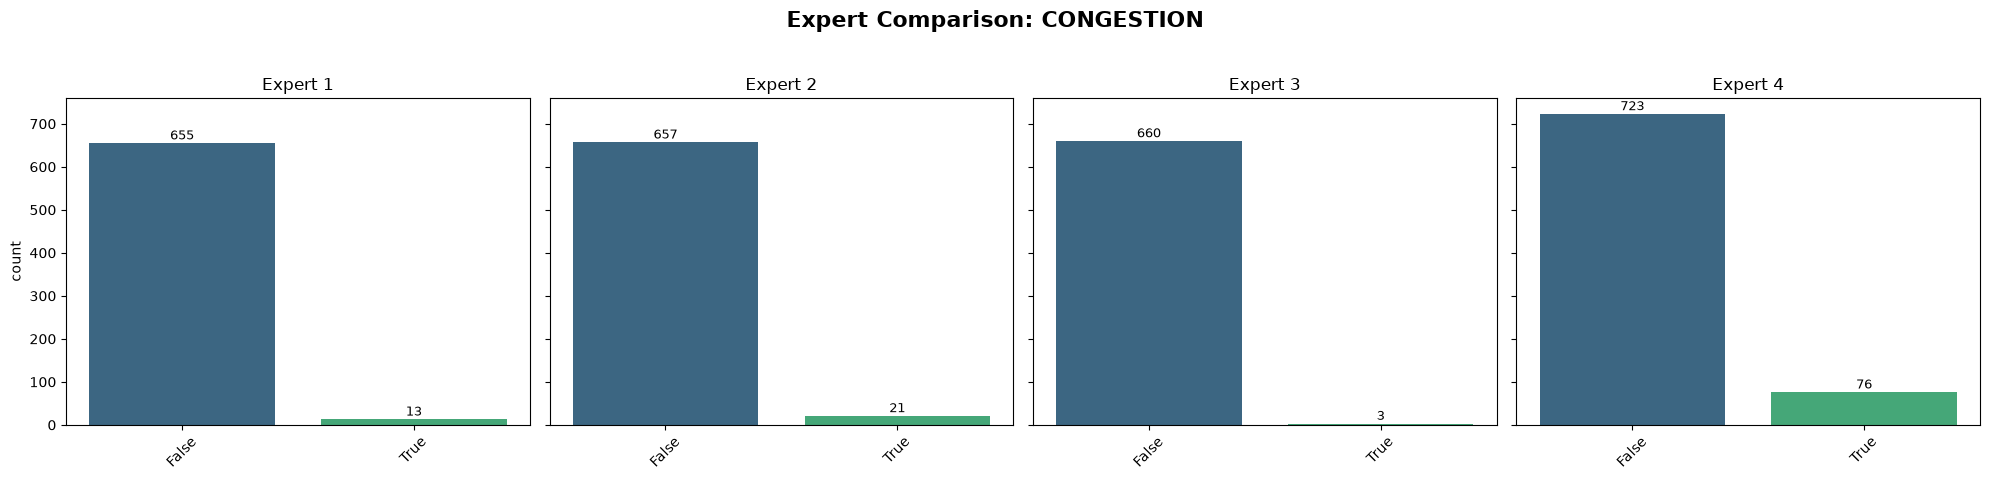

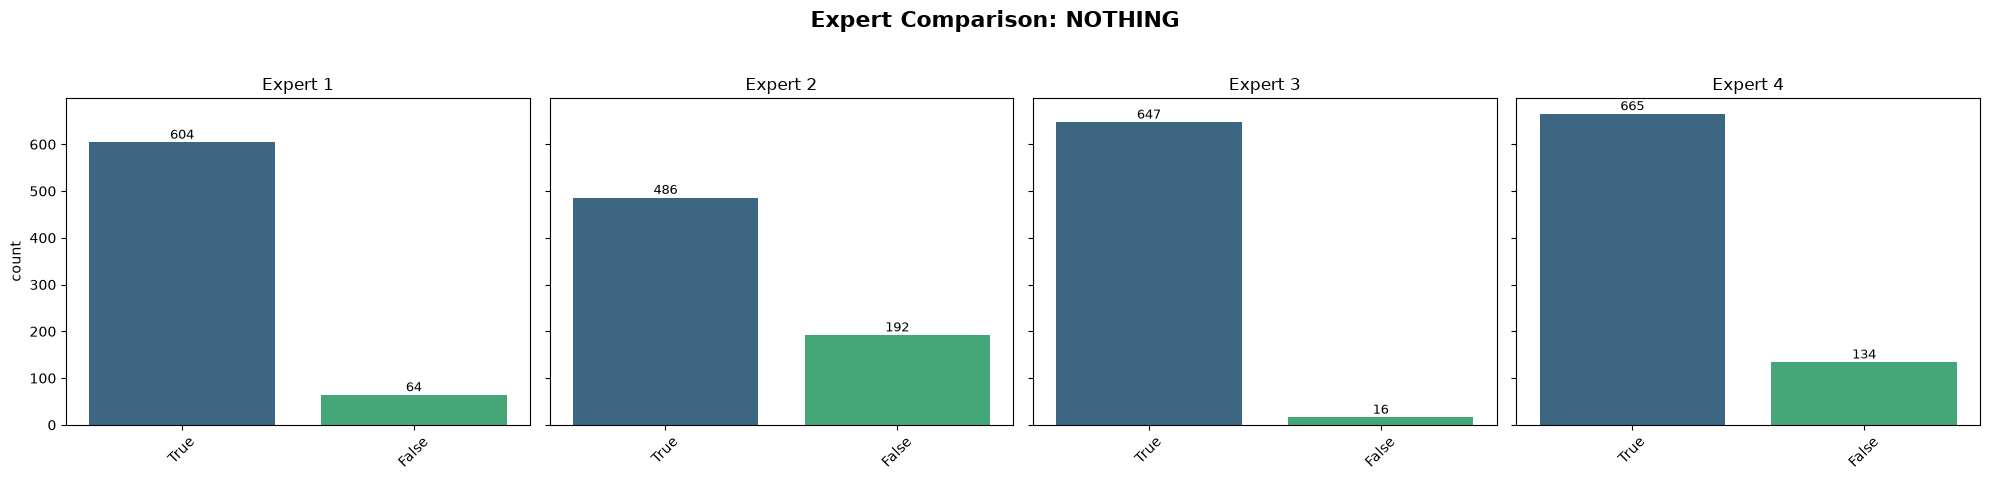

In [9]:
# 1. Define the feature groups (stubs)
expert_stubs = [
    'quality', 'diagnosis', 'cough_type', 'severity', 
    'dyspnea', 'wheezing', 'stridor', 'choking', 'congestion', 'nothing'
]

# 2. Iterate through each feature type to create a comparative row
for stub in expert_stubs:
    # Identify existing columns for this stub (e.g., quality_1, quality_2...)
    cols = [f"{stub}_{i}" for i in range(1, 5) if f"{stub}_{i}" in df_expert.columns]
    
    if not cols:
        continue
        
    # Create a 1x4 grid for the 4 experts
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    fig.suptitle(f'Expert Comparison: {stub.replace("_", " ").upper()}', fontsize=16, fontweight='bold')

    # Determine a consistent order for the X-axis across all 4 plots
    # This makes visual comparison much easier
    all_values = pd.concat([df_expert[c] for c in cols]).dropna()
    if all_values.empty:
        plt.close(fig)
        continue
    consistent_order = all_values.value_counts().index

    for i, col in enumerate(cols):
        sns.countplot(data=df_expert, x=col, ax=axes[i], order=consistent_order, palette='viridis')
        axes[i].set_title(f'Expert {i+1}')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Add count labels on top of bars for precision
        for p in axes[i].patches:
            axes[i].annotate(f'{int(p.get_height())}', 
                             (p.get_x() + p.get_width() / 2., p.get_height()), 
                             ha='center', va='center', xytext=(0, 5), 
                             textcoords='offset points', fontsize=9)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

The overall difference in distribution for e.g. quality or diagnosis prove the subjectivity of the experts labels. Therefore its best to merge all expert labels together and use the merged base as the ground truth to remove some subjectivity.

##### COVID positive analysis

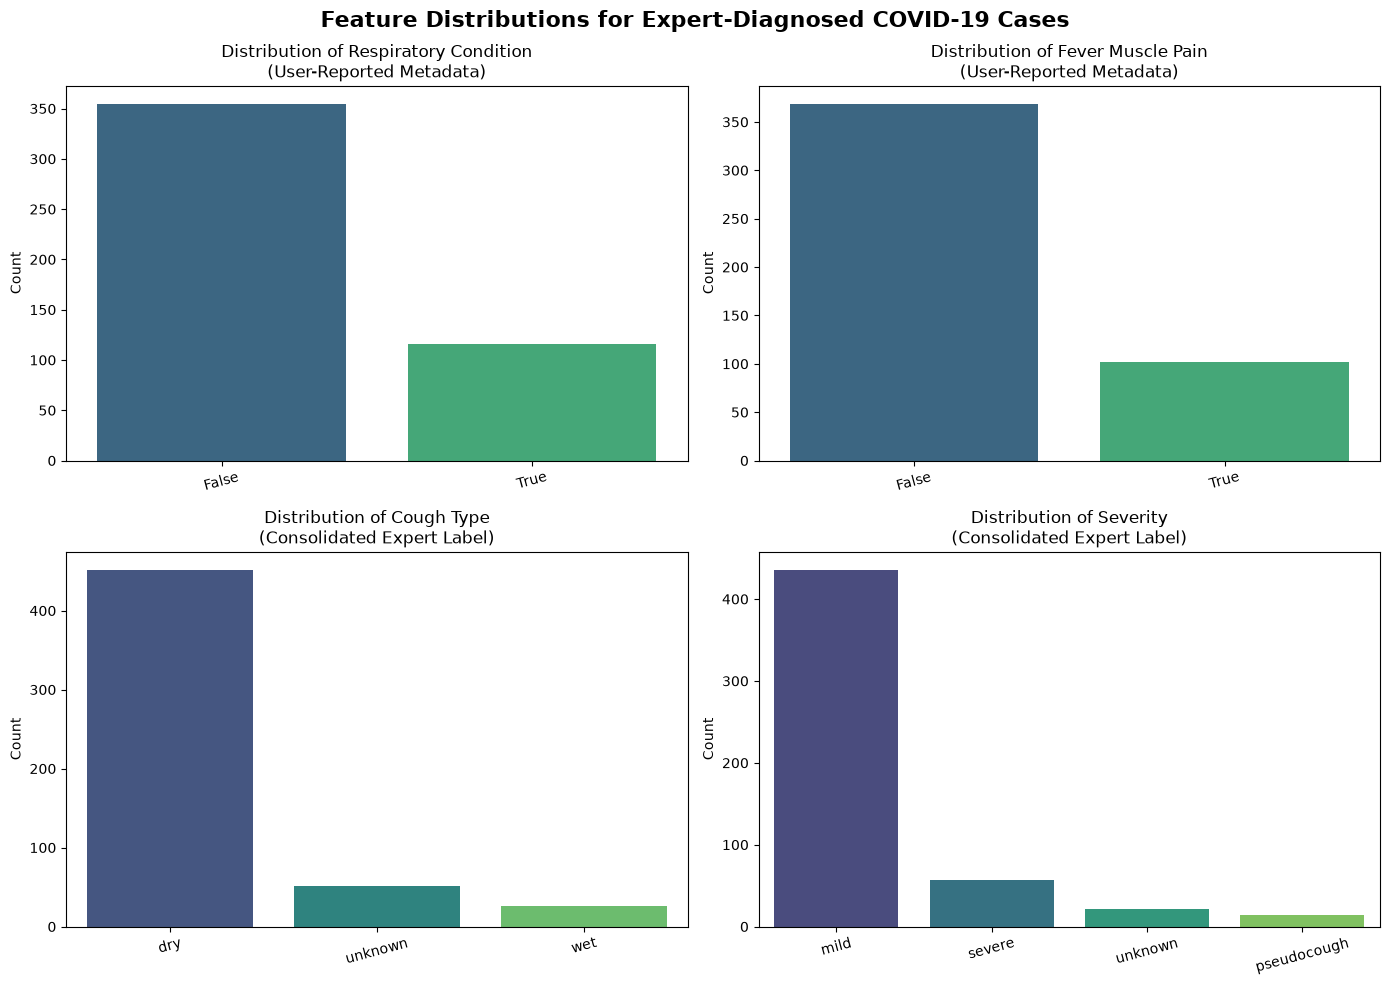

Total unique unmerged rows matching COVID-19 diagnosis: 529


In [10]:
# 1. Identify rows where AT LEAST one expert diagnosed COVID-19
covid_mask = (
    (df_expert['diagnosis_1'] == 'COVID-19') | 
    (df_expert['diagnosis_2'] == 'COVID-19') | 
    (df_expert['diagnosis_3'] == 'COVID-19') | 
    (df_expert['diagnosis_4'] == 'COVID-19')
)
df_covid_cases = df_expert[covid_mask]

# 2. Set up the plotting grid (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Distributions for Expert-Diagnosed COVID-19 Cases", fontsize=16, fontweight='bold')

# List of target features to plot
features = ['respiratory_condition', 'fever_muscle_pain', 'cough_type', 'severity']
axes_flat = axes.flatten()

# 3. Loop through features and create count plots
for i, feature in enumerate(features):
    ax = axes_flat[i]
    
    # Note: 'cough_type' and 'severity' are also split across expert columns (_1 to _4).
    # To get their true distribution, we combine the values across those expert columns.
    if feature in ['cough_type', 'severity']:
        # Coalesce: combine the 4 expert columns into a single series of data
        expert_cols = [f'{feature}_1', f'{feature}_2', f'{feature}_3', f'{feature}_4']
        plot_data = df_covid_cases[expert_cols].bfill(axis=1).iloc[:, 0]
        title_suffix = "(Consolidated Expert Label)"
    else:
        # 'respiratory_condition' and 'fever_muscle_pain' are user-reported metadata (single columns)
        plot_data = df_covid_cases[feature]
        title_suffix = "(User-Reported Metadata)"
        
    # Plotting the count distribution
    sns.countplot(x=plot_data, ax=ax, palette="viridis", order=plot_data.value_counts().index)
    
    ax.set_title(f"Distribution of {feature.replace('_', ' ').title()}\n{title_suffix}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Print out quick summary statistics
print(f"Total unique unmerged rows matching COVID-19 diagnosis: {len(df_covid_cases)}")

The diagrams show us that fever_muscle_pain and respiratory_condition do not correlate to a covid-19 diagnosis while a dry and mild cough seem to be high indicators that it is actually COVID.

##### status vs. diagnosis

--- User Status vs. Expert Diagnoses (Row percentages) ---
expert_diagnosis  COVID-19  healthy_cough  lower_infection  \
status                                                       
COVID-19             20.17          25.07            19.45   
healthy              19.26          23.75            20.15   
symptomatic          19.82          16.63            27.79   

expert_diagnosis  obstructive_disease  upper_infection  
status                                                  
COVID-19                         7.06            28.24  
healthy                          6.42            30.42  
symptomatic                      7.57            28.19  


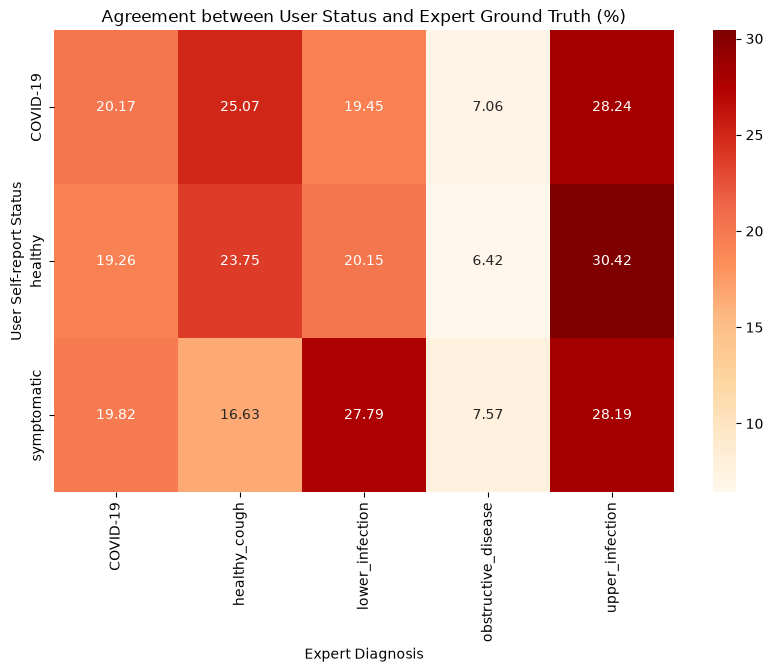

In [11]:
# Define expert diagnosis columns
diag_cols = [f'diagnosis_{i}' for i in range(1, 5) if f'diagnosis_{i}' in df_expert.columns]

# Melt the dataframe to compare User Status against any Expert Diagnosis given
df_melted = df_expert.melt(id_vars=['status'], value_vars=diag_cols, 
                           value_name='expert_diagnosis').dropna(subset=['expert_diagnosis'])

# Create the comparison table
expert_comparison = pd.crosstab(df_melted['status'], df_melted['expert_diagnosis'], 
                                 normalize='index') * 100

print("--- User Status vs. Expert Diagnoses (Row percentages) ---")
print(expert_comparison.round(2))

# Visualize the discrepancy
plt.figure(figsize=(10, 6))
sns.heatmap(expert_comparison, annot=True, cmap='OrRd', fmt='.2f')
plt.title('Agreement between User Status and Expert Ground Truth (%)')
plt.xlabel('Expert Diagnosis')
plt.ylabel('User Self-report Status')
plt.show()

There is a significant discreptancy between the users self assigned medical status and the experts diagnosis. It can be concluded that the status column might not hold any predictive power as its purely based off an individuals view.

##### Compare status & expert label against cough_detected
I suspect that a higher cough_detected score might indicate a clearer cough sound which in turn would make it easier for an expert to classify the sound correctly. This assumption is compared against the self reported status by the users

--- Cough Detected Score: Match vs. Mismatch ---
            mean  median     std  count
is_match                               
False     0.9552  0.9751  0.0479   2447
True      0.9529  0.9764  0.0511    325


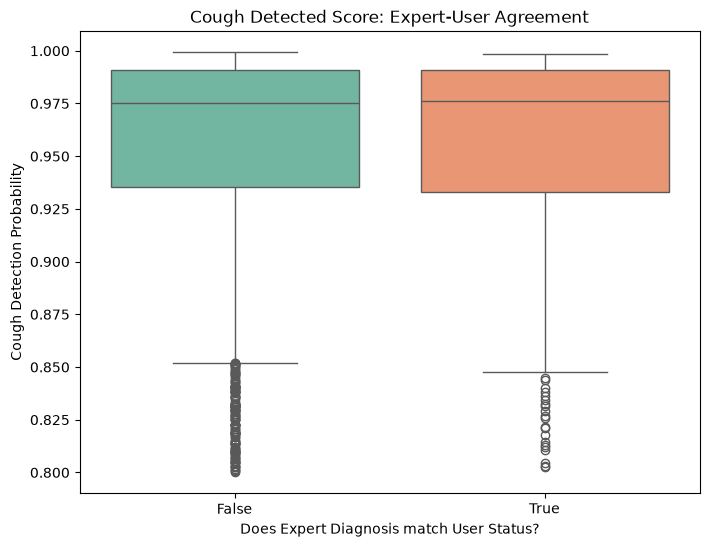

In [12]:
# 1. Map user status to expert diagnosis terms
label_map = {
    'healthy': 'healthy_cough',
    'symptomatic': 'symptomatic_cough',
    'COVID-19': 'COVID-19'
}

# 2. Extract pairs of user status and expert diagnoses
diag_cols = [f'diagnosis_{i}' for i in range(1, 5) if f'diagnosis_{i}' in df_expert.columns]
df_compare = df_expert.melt(
    id_vars=['uuid', 'status', 'cough_detected'], 
    value_vars=diag_cols, 
    value_name='expert_diagnosis'
).dropna(subset=['expert_diagnosis'])

# 3. Determine if they match
df_compare['is_match'] = df_compare.apply(
    lambda x: label_map.get(x['status']) == x['expert_diagnosis'], axis=1
)

# 4. Calculate statistics
stats = df_compare.groupby('is_match')['cough_detected'].agg(['mean', 'median', 'std', 'count'])
print("--- Cough Detected Score: Match vs. Mismatch ---")
print(stats.round(4))

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_compare, x='is_match', y='cough_detected', palette='Set2')
plt.title('Cough Detected Score: Expert-User Agreement')
plt.xlabel('Does Expert Diagnosis match User Status?')
plt.ylabel('Cough Detection Probability')
plt.show()

This shows us that there is no correlation between the cough_detected value and the classification by the experts nor any relation to the user reported status. Therefore its safe to assume that the experts classification is medically based.

#### Audio files analysis

##### Select examplary audio files
I want two samples each for these parameters:
- golden (patient & expert say COVID)
- dissociative (patient says healthy, expert says COVID)
- severity (mild)
- severity (severe)

In [13]:
df_high_qual = df_expert[df_expert['cough_detected'] >= 0.95]

# golden samples
golden_mask = (df_high_qual['status'] == 'COVID-19') & (
    (df_high_qual['diagnosis_1'] == 'COVID-19') | 
    (df_high_qual['diagnosis_2'] == 'COVID-19') | 
    (df_high_qual['diagnosis_3'] == 'COVID-19') | 
    (df_high_qual['diagnosis_4'] == 'COVID-19')
)
golden_samples = df_high_qual[golden_mask].head(2)

# dissociation samples (user != expert)
diss_mask = (df_high_qual['status'] == 'COVID-19') & (
    (df_high_qual['diagnosis_1'] == 'healthy_cough') | 
    (df_high_qual['diagnosis_2'] == 'healthy_cough') | 
    (df_high_qual['diagnosis_3'] == 'healthy_cough') | 
    (df_high_qual['diagnosis_4'] == 'healthy_cough')
)
dissociation_samples = df_high_qual[diss_mask].head(2)

# severe samples
sev_mask_severe = (
    (df_high_qual['severity_1'] == 'severe') | 
    (df_high_qual['severity_2'] == 'severe') | 
    (df_high_qual['severity_3'] == 'severe') | 
    (df_high_qual['severity_4'] == 'severe')
)
severity_samples_severe = df_high_qual[sev_mask_severe].head(2)
sev_mask_mild = (
    (df_high_qual['severity_1'] == 'mild') | 
    (df_high_qual['severity_2'] == 'mild') | 
    (df_high_qual['severity_3'] == 'mild') | 
    (df_high_qual['severity_4'] == 'mild')
)
severity_samples_mild = df_high_qual[sev_mask_mild].head(2)

# 3. Combine and display results
selected_samples = pd.concat([
    golden_samples.assign(category='Golden (Agree COVID)'),
    dissociation_samples.assign(category='Dissociation (User COVID/Exp Healthy)'),
    severity_samples_severe.assign(category='Extreme Severity (Severe)'),
    severity_samples_mild.assign(category='Extreme Severity (Mild)')
])

selected_samples['expert_diagnosis'] = selected_samples[
    ['diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4']
].bfill(axis=1).iloc[:, 0]

selected_samples['expert_severity'] = selected_samples[
    ['severity_1', 'severity_2', 'severity_3', 'severity_4']
].bfill(axis=1).iloc[:, 0]

print("--- Selected Audio Samples for Exploration ---")
print(selected_samples[['category', 'uuid', 'status', 'expert_diagnosis', 'cough_detected']])

--- Selected Audio Samples for Exploration ---
                                   category  \
1082                   Golden (Agree COVID)   
1186                   Golden (Agree COVID)   
476   Dissociation (User COVID/Exp Healthy)   
1187  Dissociation (User COVID/Exp Healthy)   
110               Extreme Severity (Severe)   
186               Extreme Severity (Severe)   
42                  Extreme Severity (Mild)   
70                  Extreme Severity (Mild)   

                                      uuid       status expert_diagnosis  \
1082  0837bd59-09c5-4098-afe3-4bcbfb0fb0e2     COVID-19         COVID-19   
1186  09115490-33a9-461c-9437-d7f71be057b0     COVID-19         COVID-19   
476   0379c586-c500-483c-83a6-95b63afe6931     COVID-19    healthy_cough   
1187  09126c08-5214-4723-94f1-7b654464eac0     COVID-19    healthy_cough   
110   00ce5b06-c302-4387-bbd7-86355a4a8c12  symptomatic  upper_infection   
186   01567151-7bb2-45ee-9aa8-a1332b5941ea          NaN         COVID-19 

##### Check file endings for selected audio files

In [14]:
selected_uuids = selected_samples['uuid'].tolist()

print(f"--- File Extension Check in {audio_path} ---")
for uid in selected_uuids:
    # Find files that start with the UUID
    matches = [f for f in all_files if f.startswith(uid)]
    
    if matches:
        for m in matches:
            extension = os.path.splitext(m)[1]
            print(f"UUID: {uid} | Filename: {m} | Extension: {extension}")
    else:
        print(f"UUID: {uid} | Status: File not found in directory")

--- File Extension Check in d:\uniDev\coughvid/../coughvid_20211012 ---
UUID: 0837bd59-09c5-4098-afe3-4bcbfb0fb0e2 | Filename: 0837bd59-09c5-4098-afe3-4bcbfb0fb0e2.json | Extension: .json
UUID: 0837bd59-09c5-4098-afe3-4bcbfb0fb0e2 | Filename: 0837bd59-09c5-4098-afe3-4bcbfb0fb0e2.webm | Extension: .webm
UUID: 09115490-33a9-461c-9437-d7f71be057b0 | Filename: 09115490-33a9-461c-9437-d7f71be057b0.json | Extension: .json
UUID: 09115490-33a9-461c-9437-d7f71be057b0 | Filename: 09115490-33a9-461c-9437-d7f71be057b0.webm | Extension: .webm
UUID: 0379c586-c500-483c-83a6-95b63afe6931 | Filename: 0379c586-c500-483c-83a6-95b63afe6931.json | Extension: .json
UUID: 0379c586-c500-483c-83a6-95b63afe6931 | Filename: 0379c586-c500-483c-83a6-95b63afe6931.webm | Extension: .webm
UUID: 09126c08-5214-4723-94f1-7b654464eac0 | Filename: 09126c08-5214-4723-94f1-7b654464eac0.json | Extension: .json
UUID: 09126c08-5214-4723-94f1-7b654464eac0 | Filename: 09126c08-5214-4723-94f1-7b654464eac0.webm | Extension: .webm


##### Plot Waveforms and spectograms

In [15]:
def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs
    # Ensure cutoff is slightly below Nyquist to keep scipy happy
    if cutoff >= nyq:
        cutoff = nyq * 0.99
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, data)

def load_and_filter_audio_file(uuid, sr=12000):
    file_name = [f for f in all_files if f.startswith(uuid) and not f.endswith('.json')][0]
    file_path = os.path.join(audio_path, file_name)
    # loading while sampling to 12kHz
    y, sr = librosa.load(file_path, sr=12000)
    # Amplitude Normalization
    # normalize each entry seperately based off its loudest point to a scale between 1 to -1
    # this should prevent the model form learning loudness instead of the sound itself
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))
    # Lowpass Filtering at 6kHz / 5.9kHz
    y_lowpass = butter_lowpass_filter(y, cutoff=5900, fs=sr, order=5)
    # Noise / Silence Removal
    y_trimmed, _ = librosa.effects.trim(y_lowpass, top_db=20)
    # flatten loudness differences between high and low frequencies using pre-emphasis
    y_filt = librosa.effects.preemphasis(y_trimmed)
    return y_filt, sr

C:\Users\hbend\AppData\Local\Temp\ipykernel_528\2234519953.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=12000)


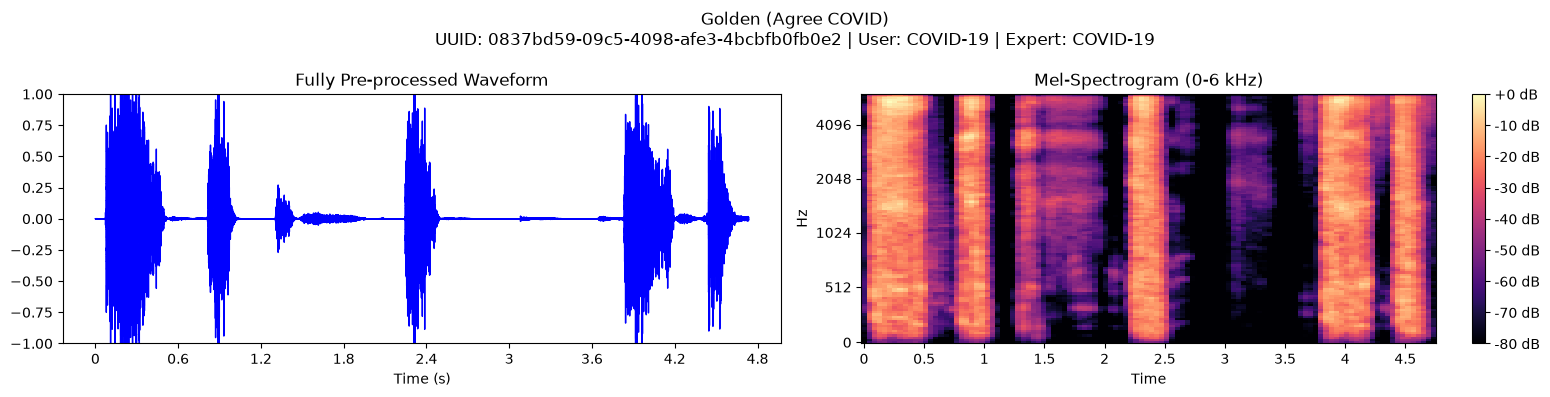

C:\Users\hbend\AppData\Local\Temp\ipykernel_528\2234519953.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=12000)


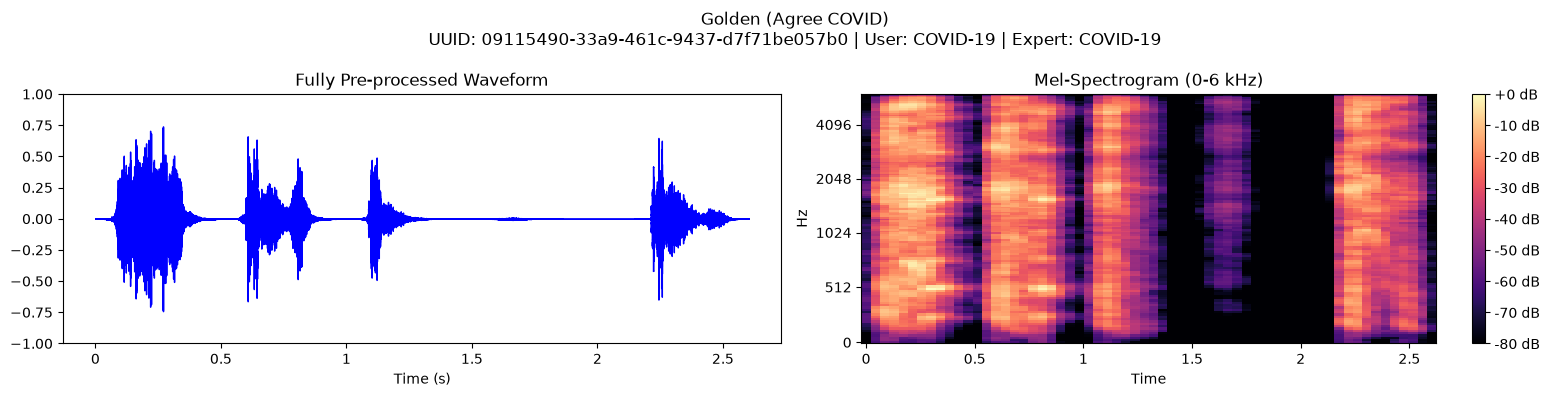

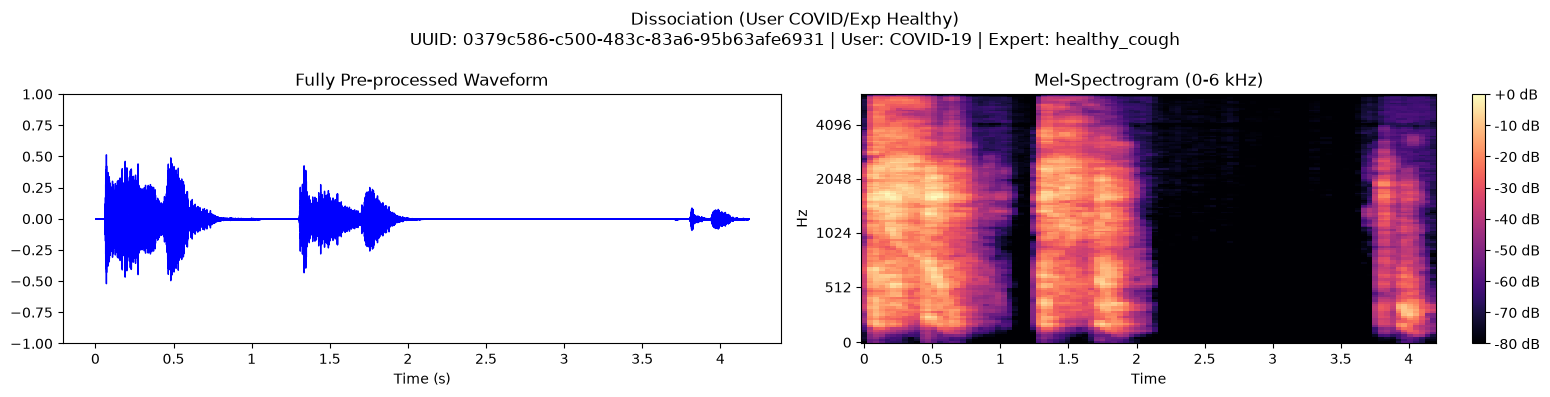

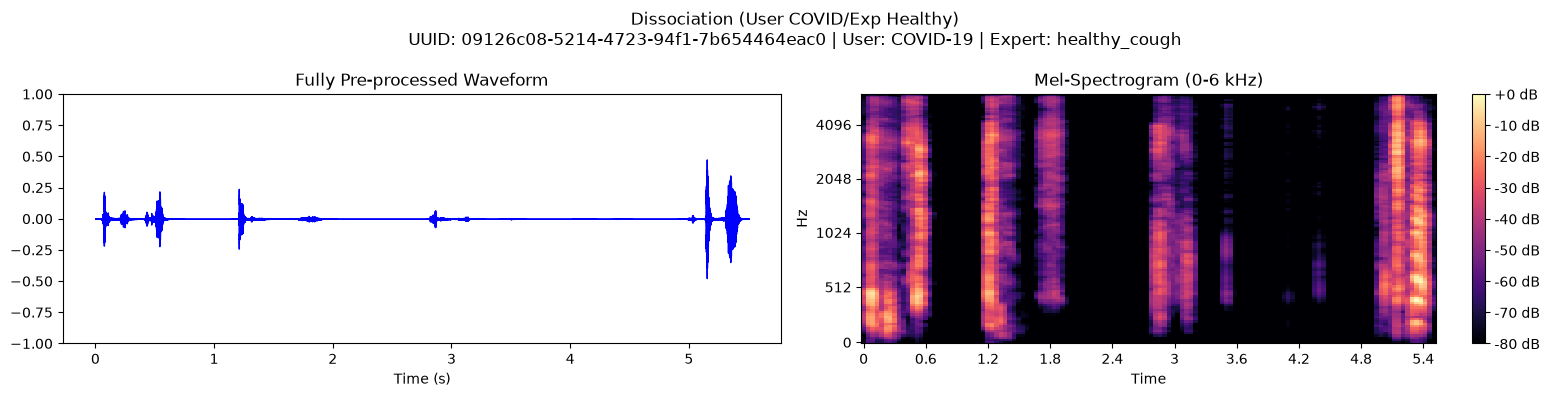

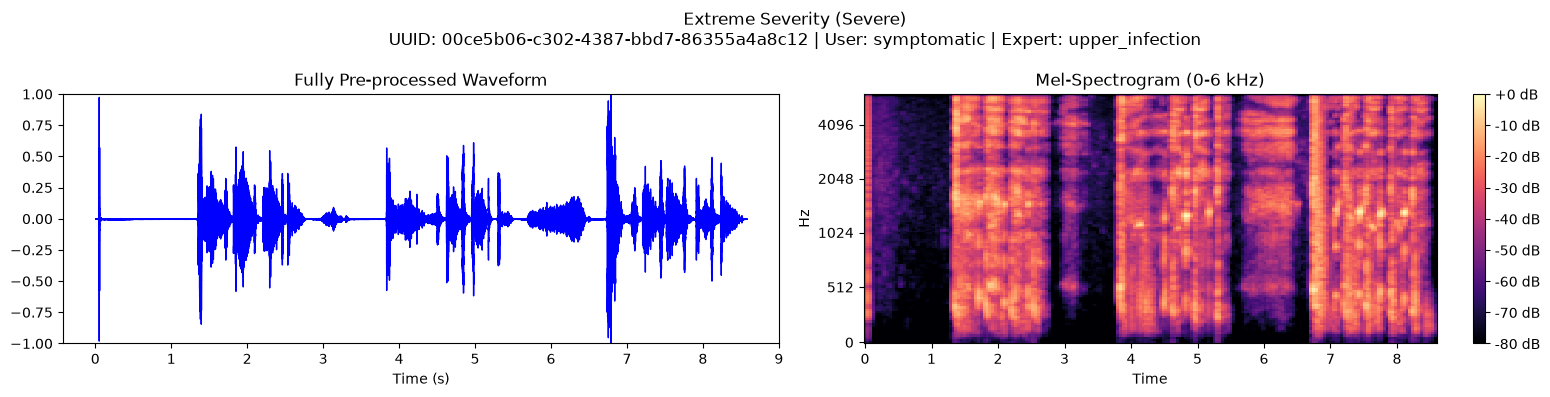

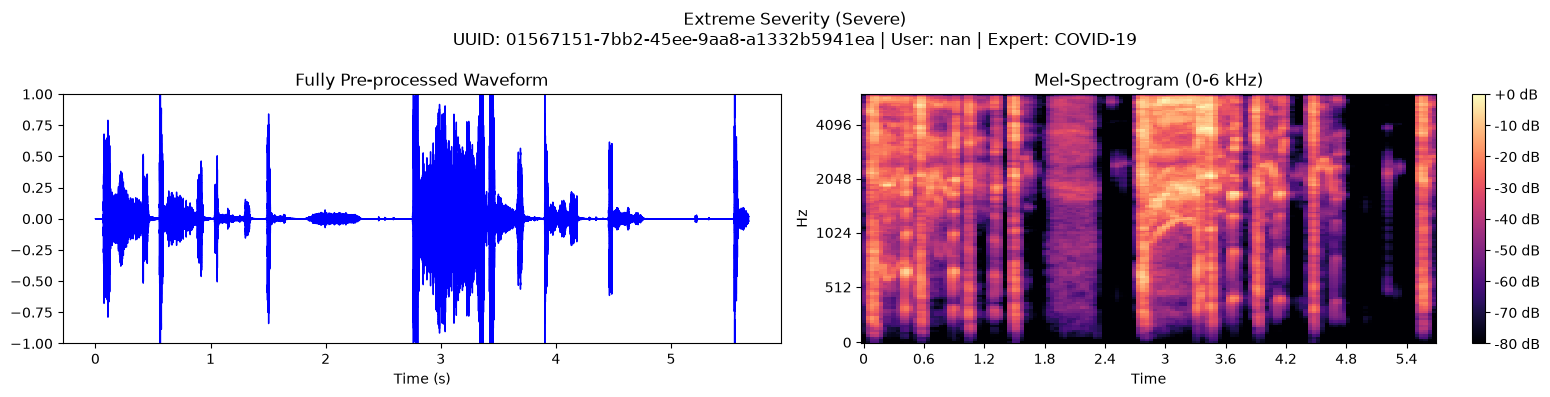

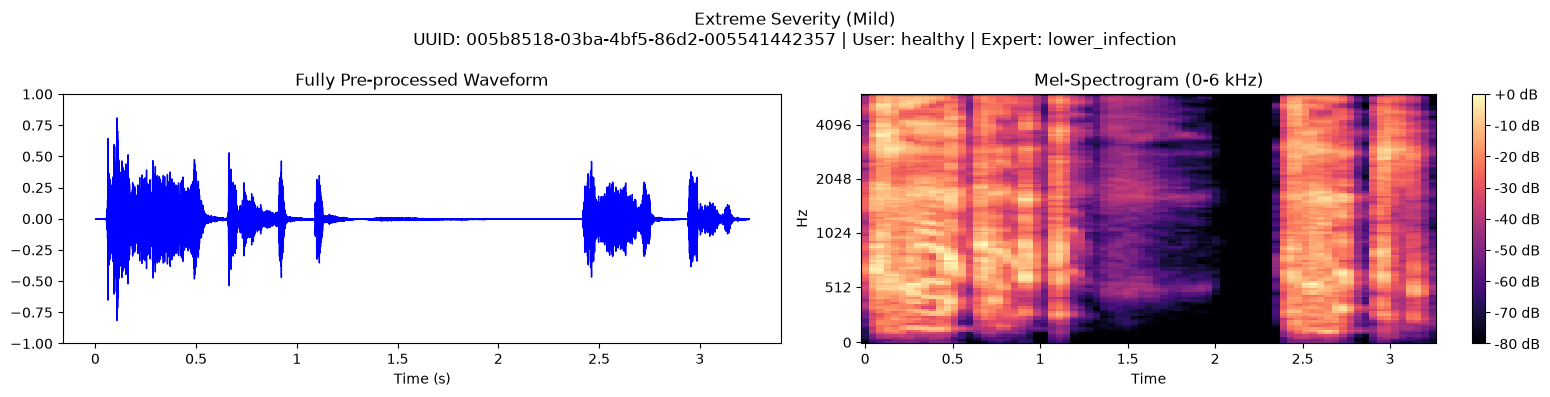

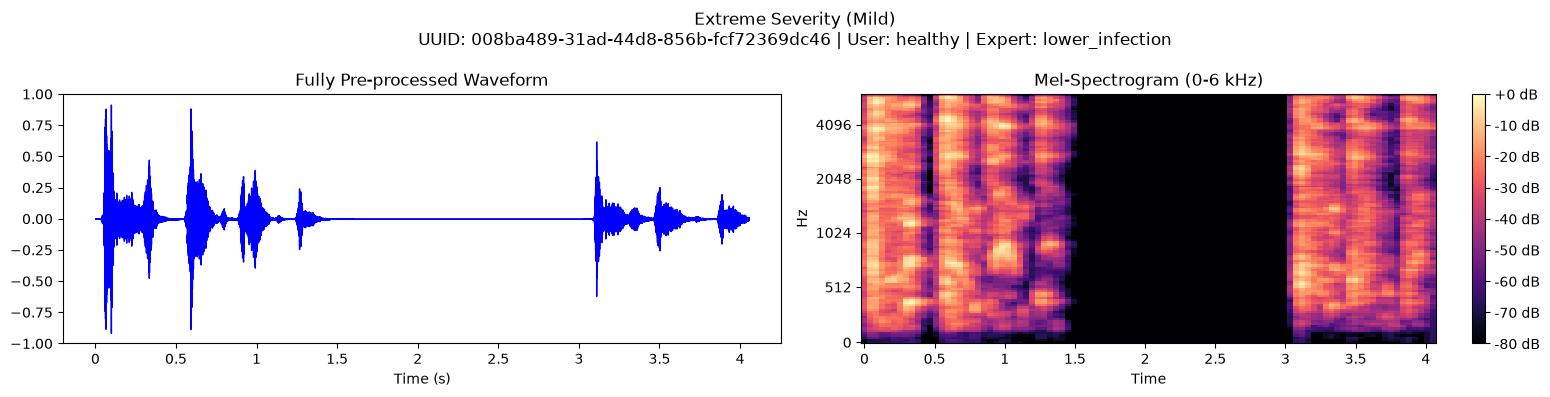

In [16]:
def plot_cough_analysis(uuid, category, status, diagnosis):
    try:
        # load & filter audio files as describe din the paper
        y_filt, sr = load_and_filter_audio_file(uuid)

        # plotting
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
        fig.suptitle(f"{category}\nUUID: {uuid} | User: {status} | Expert: {diagnosis}", fontsize=12)
        
        # Waveform Display
        librosa.display.waveshow(y_filt, sr=sr, ax=ax1, color='blue')
        ax1.set_title("Fully Pre-processed Waveform")
        ax1.set_xlabel("Time (s)")
        ax1.set_ylim(-1.0, 1.0) # Confirms amplitude normalization visually

        # Spectrogram Display (fmax altered to max allowable 6000Hz)
        S = librosa.feature.melspectrogram(y=y_filt, sr=sr
        , n_mels=128, fmax=6000)
        S_dB = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=6000, ax=ax2)
        ax2.set_title("Mel-Spectrogram (0-6 kHz)")
        fig.colorbar(img, ax=ax2, format='%+2.0f dB')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not load {uuid}: {e}")

# Run the analysis loop
for _, row in selected_samples.iterrows():
    plot_cough_analysis(row['uuid'], row['category'], row['status'], row['expert_diagnosis'])

The waveforms of COVID-19 seem to immediatly skyrocket in the beginning while healthy_coughs take more time to build up Hz. This 
The first 4 spectograms clearly show COVID-19 coughs produce more energy in the upper half (2-6kHz) compared to the healthy coughs that concentrate more up to 2.5-3 kHz. 
Severe coughs seem to concentrate heavily on the upper half of the spectograms while mild coughs fill out the whole range.
Furthermore we see in the waveforms that severe coughs have more immediate bursts after another, mild coughs rather have single burrsts with a longer decay phase.

### Data pre-processing

#### Simplify expert label column
Merge all identically named columns containing expert labels. E.g. diagnosis_1, ... , diagnosis_4

In [17]:
# Define the prefixes for the expert columns
stubs = ['quality', 'cough_type', 'dyspnea', 'wheezing', 'stridor', 
         'choking', 'congestion', 'nothing', 'diagnosis', 'severity']

# 2. Identify metadata columns to keep as identifiers
id_cols = [c for c in df_expert.columns if not any(c.endswith(f'_{i}') for i in range(1, 5))]

# Transform wide to long format
df_merged = pd.wide_to_long(
    df_expert, 
    stubnames=stubs, 
    i=id_cols, 
    j='expert_id', 
    sep='_'
).reset_index()

# Remove rows where no expert label was provided
df_merged = df_merged.dropna(subset=stubs, how='all')

print(f"Reshaped dataframe: {len(df_merged)} rows (one per expert evaluation)")
print(df_merged.columns)

Reshaped dataframe: 2808 rows (one per expert evaluation)
Index(['uuid', 'datetime', 'cough_detected', 'latitude', 'longitude', 'age',
       'gender', 'respiratory_condition', 'fever_muscle_pain', 'status',
       'status_SSL', 'expert_id', 'quality', 'cough_type', 'dyspnea',
       'wheezing', 'stridor', 'choking', 'congestion', 'nothing', 'diagnosis',
       'severity'],
      dtype='str')


#### Identify missing values

In [18]:
df_merged.isna().sum()

uuid                        0
datetime                    0
cough_detected              0
latitude                 1070
longitude                1070
age                       452
gender                    296
respiratory_condition     296
fever_muscle_pain         296
status                    296
status_SSL               1640
expert_id                   0
quality                     0
cough_type                 26
dyspnea                     0
wheezing                    0
stridor                     0
choking                     0
congestion                  0
nothing                     0
diagnosis                  36
severity                   26
dtype: int64

##### Check if missing age is related to other missing labels

In [19]:
nan_entries = df_merged[df_merged['age'].isna()]
nan_entries.isna().sum()

uuid                       0
datetime                   0
cough_detected             0
latitude                 171
longitude                171
age                      452
gender                   296
respiratory_condition    296
fever_muscle_pain        296
status                   296
status_SSL               302
expert_id                  0
quality                    0
cough_type                 5
dyspnea                    0
wheezing                   0
stridor                    0
choking                    0
congestion                 0
nothing                    0
diagnosis                  5
severity                   5
dtype: int64

load all datapoints where there are NaN for cough_type, diagnosis or severity into a csv to properly inspect them

In [20]:
# Filter df_merged for rows where 'diagnosis' OR 'severity' is NaN
nan_entries = df_merged[df_merged['diagnosis'].isna() | df_merged['severity'].isna() | df_merged['cough_type'].isna()]
# Display the entries
print(f"Number of entries with missing diagnosis or severity: {len(nan_entries)}")
nan_entries.to_csv('NaN_entries.csv', sep=";", decimal=",", index=False)

Number of entries with missing diagnosis or severity: 40


#### Remove unwanted entries

##### Remove NaN and unuseful entries
Remove the 40 entries where some of the expert labels are NaN and on top of that remove entries where the experts classified the sound as 'no_cough'

In [21]:
initial_count = len(df_merged)
# Drop rows where any of the clinical labels are missing
df_cleaned = df_merged.dropna(subset=['diagnosis', 'severity', 'cough_type'])
# Filter out 'no_cough' entries
df_cleaned = df_cleaned[df_cleaned['quality'] != 'no_cough']

# 4. Results
final_count = len(df_cleaned)
print(f"Rows before cleaning: {initial_count}")
print(f"Rows after cleaning:  {final_count}")
print(f"Total removed:        {initial_count - final_count}")

# Update your main variable
df_merged = df_cleaned

Rows before cleaning: 2808
Rows after cleaning:  2755
Total removed:        53


#### Build dataframe with possible features

##### Extract possible features form csv
Most columns don't have any value for us like position (lat/lon), datetime or the expert labels as we need to generate the classifier features based off the audio files anyways. Furthermore status_SSL and status are ignored as this is purely subjective.
I will keep the following as possible features: age, gender, respiratory_condition and fever_muscle_pain.
Columns uuid and diagnosis are kept for reference.

In [22]:
columns_of_interest = ['uuid', 'diagnosis', 'age', 'gender', 'fever_muscle_pain', 'respiratory_condition']
df_possible_features = df_merged[columns_of_interest].copy()
print(df_possible_features.columns)

Index(['uuid', 'diagnosis', 'age', 'gender', 'fever_muscle_pain',
       'respiratory_condition'],
      dtype='str')


#### Feature extraction

In [23]:
def compute_crest_factor(y):
    rms = np.sqrt(np.mean(y**2))
    if rms == 0:
        return 0
    return np.max(np.abs(y)) / rms

def load_and_basic_filter(file_path):
    # 1. Load raw audio at 12kHz
    y, sr = librosa.load(file_path, sr=12000)
    # Calculate raw crest factor BEFORE normalizing amplitude
    raw_crest_factor = compute_crest_factor(y)
    # calc raw rms before normalization
    raw_rms_mean = librosa.feature.rms(y=y).mean()
    # amplitude Normalization
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))
        
    # lowpass Filtering at 5.9kHz
    y_lowpass = butter_lowpass_filter(y, cutoff=5900, fs=sr, order=5)
    
    # forgiving silence trim
    y_trimmed, _ = librosa.effects.trim(y_lowpass, top_db=60)
    
    return y_trimmed, sr, raw_crest_factor, raw_rms_mean

def compute_psd_bands(y, sr=12000):
    # Compute the power spectral density using Welch's method
    frequencies, psd = welch(y, fs=sr, nperseg=1024)
    # define the bands as described in the paper
    bands = [
        (0, 200), (300, 425), (500, 650), (950, 1150),
        (1400, 1800), (2300, 2400), (2850, 2950), (3800, 3900)
    ]
    
    raw_band_powers = []
    for low, high in bands:
        idx = np.where((frequencies >= low) & (frequencies <= high))[0]
        # Calculate the total energy in this band
        band_power = np.trapezoid(psd[idx], frequencies[idx]) if len(idx) > 0 else 0
        # Find indices of frequencies that fall within the current band
        raw_band_powers.append(band_power)
        
    total_power = sum(raw_band_powers) + 1e-8
    psd_features = {f'psd_band_{i+1}': p / total_power for i, p in enumerate(raw_band_powers)}
    
    return psd_features

def compute_eepd_features(y, sr=12000, num_bands=19):
    # Logarithmically or linearly space 19 bands between 50Hz and 6000Hz
    edges = np.logspace(np.log10(50), np.log10(5000), num_bands + 1)
    eepd_means = []
    
    for i in range(num_bands):
        low, high = edges[i], edges[i+1]
        # Apply Butterworth Bandpass Filter for this specific sub-band
        sos = butter(4, [low, high], btype='bandpass', fs=sr, output='sos')
        filtered_signal = sosfiltfilt(sos, y)
        # Extract the Hilbert Envelope
        amplitude_envelope = np.abs(hilbert(filtered_signal))
        
        log_envelope = 20 * np.log10(amplitude_envelope + 1e-6)
        eepd_means.append(np.mean(log_envelope))
        
    return eepd_means

def gen_extracted_features():

    features_dict = {
        'rms_mean': [], 'rms_std': [], 'raw_rms_mean': [],
        'zcr_mean': [], 'zcr_std': [],
        'spectral_centroid_mean': [], 'spectral_centroid_std': [],
        'spectral_flatness_mean': [], 'spectral_flatness_std': [],
        'crest_factor': []
    }

    num_mfccs = 13
    for m in range(1, num_mfccs + 1):
        features_dict[f'mfcc_{m}_mean'] = []
        features_dict[f'mfcc_{m}_std'] = []
    for i in range(1, 9):
        features_dict[f'psd_band_{i}'] = []
    for i in range(1, 20):
        features_dict[f'eepd_band_{i}'] = []

    file_dict = {f.split('.')[0]: f for f in all_files if not f.endswith('.json')}

    print("Extracting features cleanly...")
    for uuid in tqdm(df_possible_features['uuid']):
        try:
            if uuid in file_dict:
                file_path = os.path.join(audio_path, file_dict[uuid])
                y_filt, sr, cf, raw_rms_mean = load_and_basic_filter(file_path)
                
                rms = librosa.feature.rms(y=y_filt)
                zcr = librosa.feature.zero_crossing_rate(y=y_filt)
                sc = librosa.feature.spectral_centroid(y=y_filt, sr=sr)
                sf = librosa.feature.spectral_flatness(y=y_filt)
                mfccs = librosa.feature.mfcc(y=y_filt, sr=sr, n_mfcc=num_mfccs)
                
                psd_dict = compute_psd_bands(y_filt, sr=sr)
                eepd_list = compute_eepd_features(y_filt, sr=sr)

                features_dict['rms_mean'].append(np.mean(rms))
                features_dict['rms_std'].append(np.std(rms))
                features_dict['raw_rms_mean'].append(raw_rms_mean)
                features_dict['zcr_mean'].append(np.mean(zcr))
                features_dict['zcr_std'].append(np.std(zcr))
                features_dict['spectral_centroid_mean'].append(np.mean(sc))
                features_dict['spectral_centroid_std'].append(np.std(sc))
                features_dict['spectral_flatness_mean'].append(np.mean(sf))
                features_dict['spectral_flatness_std'].append(np.std(sf))
                features_dict['crest_factor'].append(cf)  
                
                for m in range(num_mfccs):
                    features_dict[f'mfcc_{m+1}_mean'].append(np.mean(mfccs[m]))
                    features_dict[f'mfcc_{m+1}_std'].append(np.std(mfccs[m]))
                for i in range(8):
                    features_dict[f'psd_band_{i+1}'].append(psd_dict[f'psd_band_{i+1}'])
                for i in range(19):
                    features_dict[f'eepd_band_{i+1}'].append(eepd_list[i])
            else:
                for key in features_dict.keys():
                    features_dict[key].append(np.nan)
                    
        except Exception:
            for key in features_dict.keys():
                features_dict[key].append(np.nan)

    df_extracted = df_possible_features.copy()
    for feature_name, data_list in features_dict.items():
        df_extracted[feature_name] = data_list

    df_extracted.to_csv("extracted_features_sample.csv", sep=";", decimal=",", index=False)
    df_extracted.head()

df_extracted =  pd.read_csv("extracted_features_sample.csv", index_col=0, sep=";", decimal=",") if os.path.exists("extracted_features_sample.csv") else gen_extracted_features()

#### Analyze features correlation

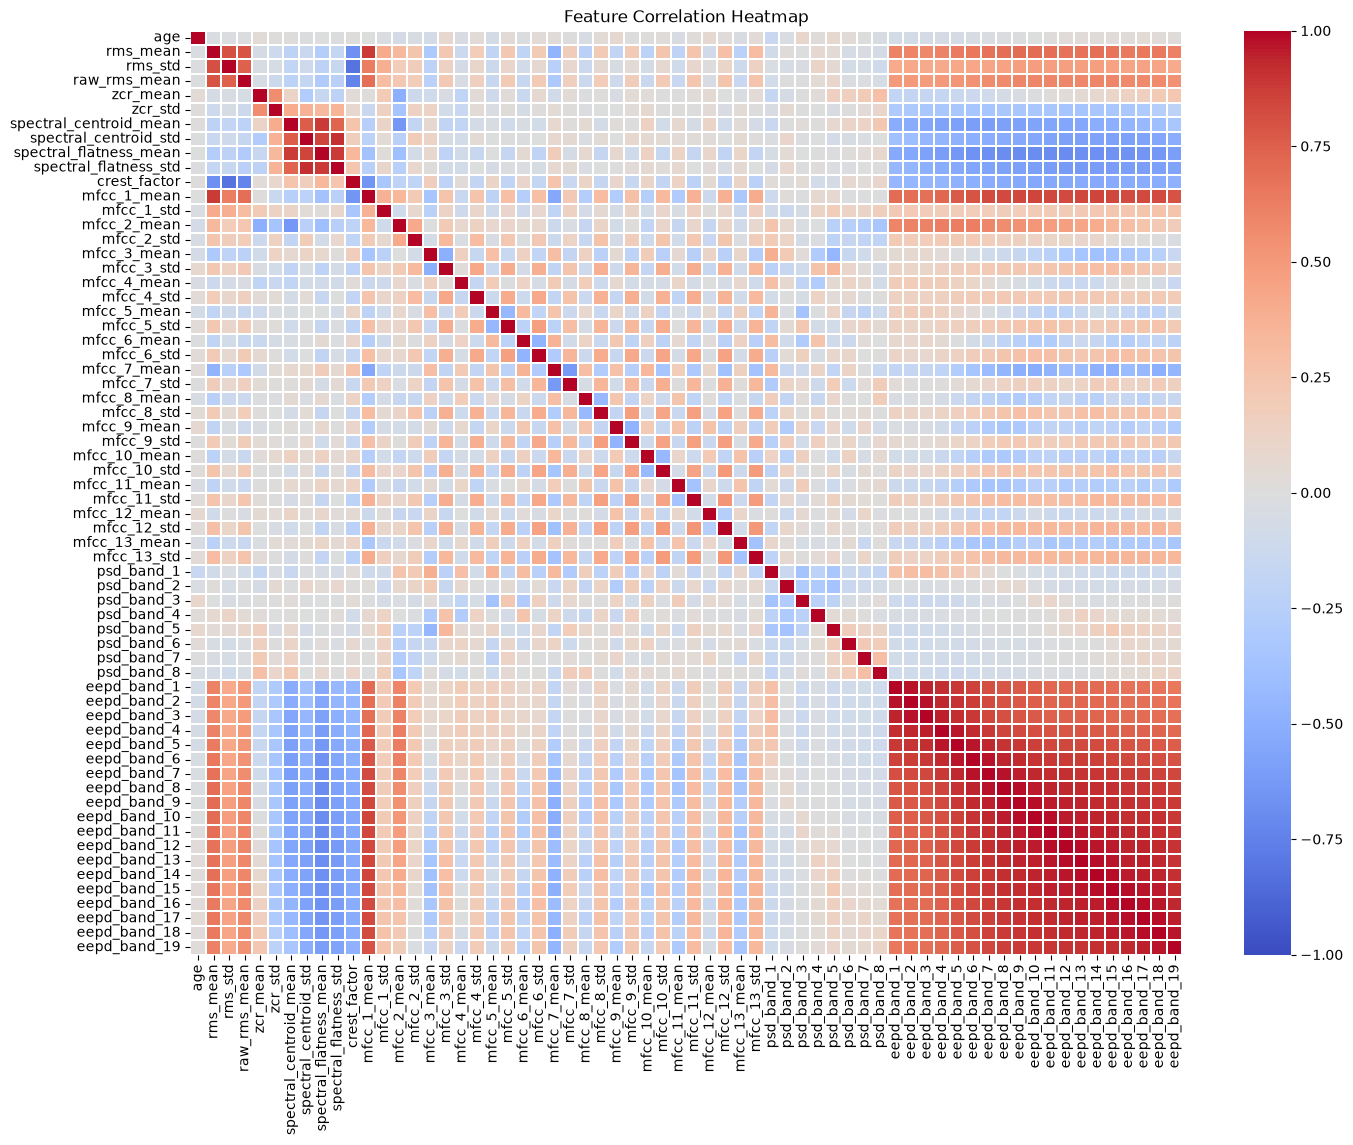

In [24]:
numeric_features = df_extracted.select_dtypes(include=['float64', 'int64'])
# compute the Pearson correlation matrix
corr_matrix = numeric_features.corr()
# plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, center=0, annot=False, linewidths=0.1)
plt.title('Feature Correlation Heatmap')
plt.show()

ALL eepd band feature correlate highly with each other. This won't be a problem for tree-based, gradient-boosting or nerual networks. Yet it will trouble logistic regression, SVM or naive bayes. Therefore we should try to minimize the correlation by perhaps removing some of the features.

##### run PCA for eepd bands

In [25]:
# 1. Isolate the highly correlated EEPD columns
eepd_cols = [f'eepd_band_{i}' for i in range(1, 20)]

# Handle any random NaN values safely by filling them with the column mean 
# (PCA cannot handle missing values)
df_clean_eepd = df_extracted[eepd_cols].fillna(df_extracted[eepd_cols].mean())

# 2. Standardize the EEPD features (Crucial for PCA)
scaler = StandardScaler()
eepd_scaled = scaler.fit_transform(df_clean_eepd)

# 3. Apply PCA
# Let's compress 19 features down into 3 principal components
n_components = 3
pca = PCA(n_components=n_components)
eepd_pca = pca.fit_transform(eepd_scaled)

# Check how much information (variance) we successfully kept
explained_variance = np.sum(pca.explained_variance_ratio_)
print(f"Total variance captured by {n_components} components: {explained_variance * 100:.2f}%")

# 4. Convert components into a clean DataFrame
pca_cols = [f'eepd_pca_{i+1}' for i in range(n_components)]
df_eepd_components = pd.DataFrame(eepd_pca, columns=pca_cols, index=df_extracted.index)

# 5. Merge components back and DROP the original 19 correlated columns
df_pca = df_extracted.drop(columns=eepd_cols)
df_pca = pd.concat([df_pca, df_eepd_components], axis=1)

print("\nTransformation complete! Shape of final ML dataset:", df_pca.shape)

Total variance captured by 3 components: 96.47%

Transformation complete! Shape of final ML dataset: (2755, 52)


##### re-analyze correlations

Text(0.5, 1.0, 'Feature Correlation Heatmap')

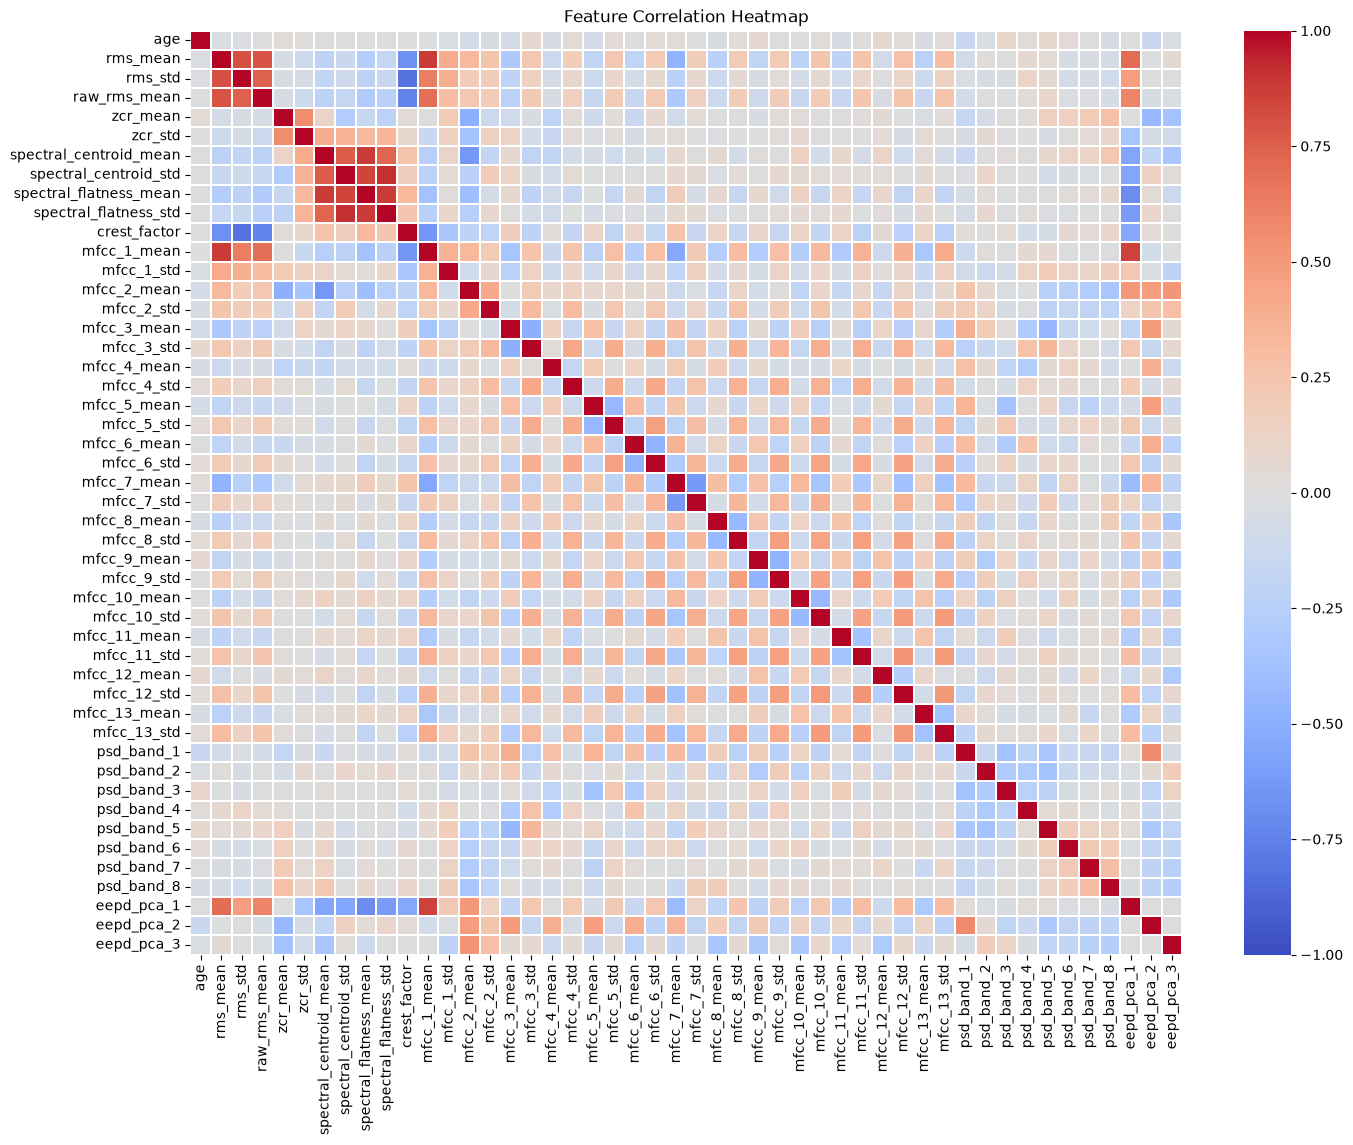

In [26]:
numeric_features = df_pca.select_dtypes(include=['float64', 'int64'])
# compute the Pearson correlation matrix
corr_matrix = numeric_features.corr()
# plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, center=0, annot=False, linewidths=0.1)
plt.title('Feature Correlation Heatmap')
#plt.show()

The last remaining correlations are mfcc_1_mean with eepd_pca_1. mfcc_1_mean and eepd_pca_1 track global signal energy which means i can safely drop one of them.
The other correlation is between spectral flatness&centroid

##### drop remaining correlations

In [27]:
columns_to_drop = ['eepd_pca_1', 'spectral_centroid_std', 'spectral_flatness_std']
df_features_cleaned = df_pca.drop(columns=columns_to_drop)

##### Add median/ 'unknown' value for missing fields

In [28]:
df_features_cleaned['age'] = df_features_cleaned['age'].fillna(df_features_cleaned['age'].median())
df_features_cleaned['gender'] = df_features_cleaned['gender'].fillna('unknown')
df_features_cleaned['fever_muscle_pain'] = df_features_cleaned['fever_muscle_pain'].fillna('unknown')
df_features_cleaned['respiratory_condition'] = df_features_cleaned['respiratory_condition'].fillna('unknown')

#### Evaluate feature importance

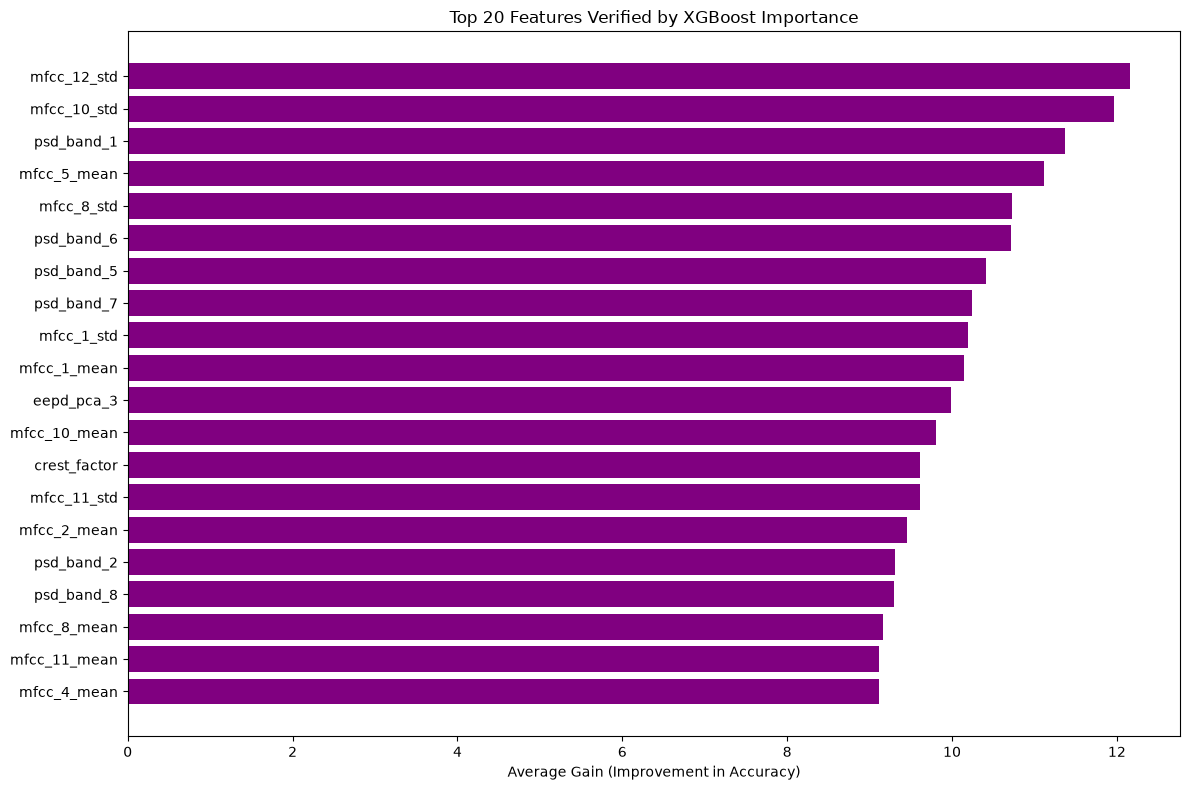

In [29]:
X = df_features_cleaned.select_dtypes(include=[np.number]).drop(columns=['diagnosis', 'uuid', 'status'], errors='ignore')
y = (df_features_cleaned['diagnosis'] == 'COVID-19').astype(int)

X_all = X.copy() 
y_binary = y.copy()

# Train/Test Split 80%/20%
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
scale_weight = neg_count / pos_count

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# XGBoost for initial feature importance
importance_gain = xgb_model.get_booster().get_score(importance_type='gain')

xgb_df = pd.DataFrame({
    'feature': list(importance_gain.keys()),
    'xgboost_gain': list(importance_gain.values())
}).sort_values('xgboost_gain', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(xgb_df['feature'].head(20)[::-1], xgb_df['xgboost_gain'].head(20)[::-1], color='purple')
plt.xlabel('Average Gain (Improvement in Accuracy)')
plt.title('Top 20 Features Verified by XGBoost Importance')
plt.tight_layout()
plt.show()

#### Save final feature selection

In [30]:
if not os.path.exists("features_cleaned.csv"):
    df_features_cleaned.to_csv("features_cleaned.csv", sep=";", decimal=",", index=False)

### Supervised ML

feature scaling using z-score for log reg and SVM

In [31]:
def split_data(df, apply_smote):
    X = df.select_dtypes(include=["number", "bool"]).drop(columns=['diagnosis'], errors='ignore')
    y = (df['diagnosis'] == 'COVID-19').astype(int).values

    # train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # use scaling & smote only for logistic regression/ SVM
    if(apply_smote):
        # feature scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        #smote = SMOTE(random_state=42)
        #X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
        #print(f"Original training set class distribution: {np.bincount(y_train)}")
        #print(f"Resampled training set class distribution: {np.bincount(y_train_smote)}")
        return X_train_scaled, X_test_scaled, y_train, y_test
    return X_train, X_test, y_train, y_test

# def feature_scale(X_train, X_test):
#     # feature scaling
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
#     return X_train_scaled, X_test_scaled

def one_hot_encode(df):
    # one-hot encode categorical variables
    return pd.get_dummies(df, columns=['gender', 'fever_muscle_pain', 'respiratory_condition'], drop_first=True)

#### Logistic Regression

In [32]:
def run_log_reg(X_train, X_test, y_train, y_test):
    model = LogisticRegression(class_weight='balanced', max_iter=50, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return (
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
    )
    
def evaluate(df, label):
    X_train, X_test, y_train, y_test = split_data(df, True)

    acc, f1, auc = run_log_reg(X_train, X_test, y_train, y_test)

    print(f"--- {label} ---")
    print(f"Accuracy: {acc:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"ROC-AUC: {auc:.3f}\n")

df_ml_ready = df_features_cleaned.copy()
metadata_columns = ['age', 'gender', 'fever_muscle_pain', 'respiratory_condition']

metadata_df = one_hot_encode(df_ml_ready[['diagnosis'] + metadata_columns].copy())
audio_df = df_ml_ready.copy().drop(columns=metadata_columns, errors='ignore')
all_df = one_hot_encode(df_ml_ready.copy())
evaluate(metadata_df, "Metadata Features")
evaluate(audio_df, "Audio Features")
evaluate(all_df, "All Features")

--- Metadata Features ---
Accuracy: 0.443
F1-score: 0.267
ROC-AUC: 0.479

--- Audio Features ---
Accuracy: 0.559
F1-score: 0.296
ROC-AUC: 0.545

--- All Features ---
Accuracy: 0.574
F1-score: 0.311
ROC-AUC: 0.545



Metadata-features alone have a lower accuracy 0.44 compared to the accuracy of the audio features 0.54. SImilar for ROC-AUC. Only F1-score remains similar but improves when both are added together.

In [33]:
def run_log_reg_cv(X, y):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ])

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1",
            "roc_auc": "roc_auc"
        },
        return_train_score=False
    )

    print("=== 10-Fold CV Results ===")
    print(f"Accuracy: {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")
    print(f"F1-score:  {scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}")
    print(f"ROC-AUC:   {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}")

log_reg_CV_df = one_hot_encode(df_ml_ready.copy())
X = log_reg_CV_df.copy().drop(columns=['diagnosis'])
y = (log_reg_CV_df.copy()['diagnosis'] == 'COVID-19').astype(int)
run_log_reg_cv(X, y)


=== 10-Fold CV Results ===
Accuracy: 0.560 ± 0.015
F1-score:  0.314 ± 0.025
ROC-AUC:   0.560 ± 0.023


Accuracy of 10-fold CV is with 0.56 almost the same as 0.57 for the initial train/test split. It's quite similar for ROC-AUC. This shows that there is no major 'lucky draw' in the initial train/test split.

The Results in itself are pretty bad as they are only a little bit better than taking random chance. Yet if we think back to the XGBoost feature importance I can safely say that useful features were extracted. FOr now I would suggest that this is only due to the Linearity gap and I see better results for e.g. Random forest.

#### Random Forest

In [34]:
def run_random_forest(X, y, single_run=True, n_estimators=200, max_depth=8, min_samples_leaf=4, max_features='sqrt'):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    rf_model = RandomForestClassifier(
        n_estimators=n_estimators, 
        class_weight="balanced_subsample", 
        random_state=42,
        max_depth=max_depth, # Much safer for noisy crowdsourced data
        min_samples_leaf=min_samples_leaf, # Prevents individual trees from memorizing noise
        max_features=max_features
    )
    rf_model.fit(X_train, y_train)
    # validation
    y_pred = rf_model.predict(X_test)
    y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

    # Metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    result = {"accuracy": round(accuracy, 5), "f1_score": round(f1, 5), "roc_auc": round(roc_auc, 5), "sensitivity": round(float(sensitivity), 5), "specificity": round(float(specificity), 5)}

    if(single_run):
        perm_importance = permutation_importance(
            rf_model,
            X_test,
            y_test,
            n_repeats=10,
            random_state=42,
            scoring="roc_auc"
        )
        
        # SHAP
        # Ensure numeric
        X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
        X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

        # Align columns
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

        # SHAP
        explainer = shap.Explainer(rf_model, X_train)
        shap_values = explainer(X_test)
        print("---- SHAP VALUES ----")
        #print(shap_values)
        shap.summary_plot(shap_values[:, :, 1], X_test)

        # feature importance
        feature_importance = pd.DataFrame({
            "feature": X_train.columns,
            "feature_importance": rf_model.feature_importances_,
            "permutation_importance": perm_importance.importances_mean
        })
        feature_importance = feature_importance.sort_values(
            by="feature_importance",
            ascending=False
        )
        return result, feature_importance
    
    feature_importance = None
    return result, feature_importance

##### Plain random forest + feature importance

str


Background dataset has 2204 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2204 when initializing the masker.
 94%|=================== | 1038/1102 [00:13<00:00]       

---- SHAP VALUES ----


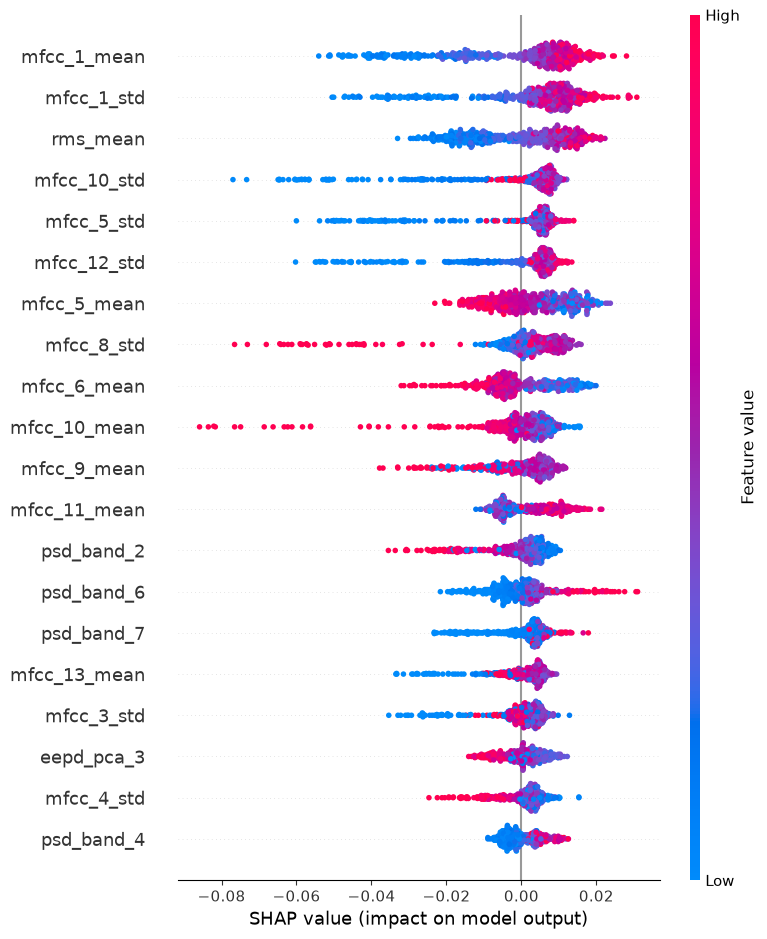

--- BASE RANDOM FOREST RESULTS ---
{'accuracy': 0.73684, 'f1_score': 0.20765, 'roc_auc': 0.52937, 'sensitivity': 0.17273, 'specificity': 0.87755}
         feature  feature_importance  permutation_importance
28   mfcc_10_std            0.034200               -0.005373
27  mfcc_10_mean            0.032797                0.003970
10    mfcc_1_std            0.032594                0.004892
24    mfcc_8_std            0.032478               -0.012119
9    mfcc_1_mean            0.030413               -0.000373
18    mfcc_5_std            0.029183                0.001346
32   mfcc_12_std            0.028875               -0.001006
25   mfcc_9_mean            0.028266               -0.005542
17   mfcc_5_mean            0.027470               -0.002403
19   mfcc_6_mean            0.025998                0.002350


In [35]:
# 1. Ensure absolute column consistency
df_encoded = pd.get_dummies(df_ml_ready.copy(), columns=['gender', 'fever_muscle_pain', 'respiratory_condition'], drop_first=True)
# 2. Define X and y BEFORE the split
X = df_encoded.select_dtypes(include=['number'])
y = (df_encoded['diagnosis'] == 'COVID-19').astype(int)
print(X.columns.dtype)

result, feature_importance = run_random_forest(X, y)

print("--- BASE RANDOM FOREST RESULTS ---")
print(result)
feature_importance.to_csv("feature_importance.csv", sep=";", decimal=",", index=False)
print(feature_importance.head(10))


Higher values of mfcc_1_mean, mfcc_1_std, rms_mean push the model towards COVID-positive prediciton.
Higher values of mfcc_10_mean push the model towards COVID-negative prediction.

The SHAP values show that the effect of the different features are generally small. Furthermore there is substantial overlap between red and blue ponts and no feature shows a clean separation between high and low values. I would expect a highly disciminative feature to have most high and low values clustered on different sides. Thus the extracted features appear to contain only weak information for predicting the COVID status of a cough sound. This is consistent with the results from logistic regresison and random forest. 

Looking at result of the different ml models I feel like I can not accurately determine which feature or which features hold the most predictive power over the classification fo COVID-19 because the influence of each feature is too little. There is no single feature that holds massively more predictive power over the COVID-19 label than any other feature.

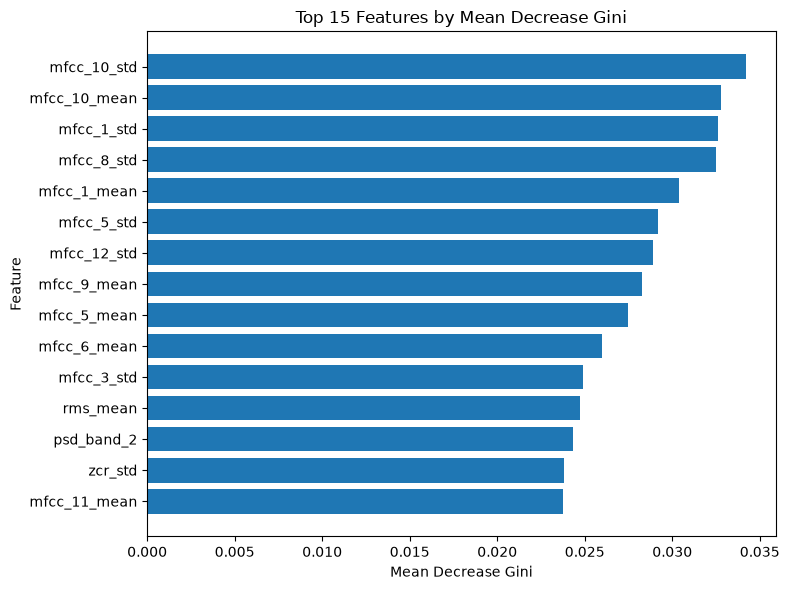

In [36]:
top_features = (
    feature_importance
    .sort_values("feature_importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["feature"],
    top_features["feature_importance"]
)

plt.xlabel("Mean Decrease Gini")
plt.ylabel("Feature")
plt.title("Top 15 Features by Mean Decrease Gini")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

This shows that especially mfcc_1_std or mfcc_10_std have a high feature importance. The difference between the most and least important feature here is with 0.035-0.024=0.011. This is a small spread meaning that no single feature dominates. This suggests the model extracts small amounts of information from many features instead of relying on a few, strong features.

Comparing this with the results from the SHAP values tells me that feature importance does not guarantee predictive power in this case. 

Also this shows that the extracted features do not contain random noise as feature importance would be unstable or the SHAP values closer at 0. Instead we can safely say that the predictive power of the features themselves is low. In order to continue working and improving the results, I suspect I would need to review the preprocessing and feature extraction more closely. Yet this is no guarantee that I could definetely improve the discriminative power using the coughvid database.

##### Random forest without metadata features

Metadata features have the lowest feature importance value for random forest.

Background dataset has 2204 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2204 when initializing the masker.
 96%|=================== | 1056/1102 [00:17<00:00]       

---- SHAP VALUES ----


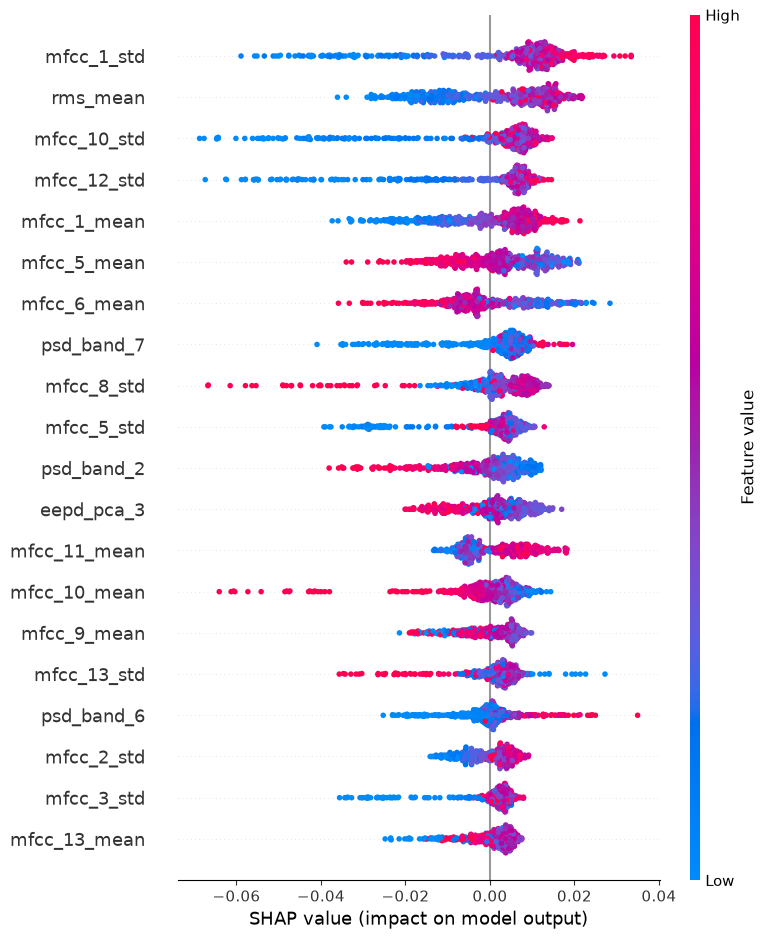

--- RANDOM FOREST WITHOUT METADATA RESULTS ---
{'accuracy': 0.74955, 'f1_score': 0.22472, 'roc_auc': 0.52572, 'sensitivity': 0.18182, 'specificity': 0.89116}


In [37]:
# 2. Define X and y BEFORE the split
X = df_ml_ready.copy().drop(columns=['diagnosis', 'fever_muscle_pain', 'respiratory_condition', 'gender', 'age'], errors='ignore')
y = (df_ml_ready.copy()['diagnosis'] == 'COVID-19').astype(int)

result, feature_importance = run_random_forest(X, y)

print("--- RANDOM FOREST WITHOUT METADATA RESULTS ---")
print(result)
feature_importance.to_csv("feature_importance.csv", sep=";", decimal=",", index=False)

This shows that the existence or absence of metadata does not influence the model strongly. It slightly improves specificity (COVID-19-negative cases correctly classified) but reduces sensitivity (COVID-19-positive cases correctly classified).


    f1_score  roc_auc  specificity  sensitivity  n_estimators  max_depth  \
0    0.32020  0.53680      0.47619      0.59091             5          2   
1    0.32020  0.53680      0.47619      0.59091             5          2   
2    0.31183  0.53244      0.53741      0.52727             5          3   
3    0.30446  0.53903      0.51701      0.52727             5          3   
4    0.29912  0.53537      0.59184      0.46364             5          4   
5    0.27778  0.52712      0.61678      0.40909             5          4   
6    0.28044  0.52280      0.72109      0.34545             5          6   
7    0.23913  0.50290      0.69841      0.30000             5          6   
8    0.26471  0.50891      0.71429      0.32727             5          8   
9    0.22745  0.49337      0.73696      0.26364             5          8   
10   0.33333  0.56130      0.55782      0.55455            10          2   
11   0.33333  0.56130      0.55782      0.55455            10          2   
12   0.33333

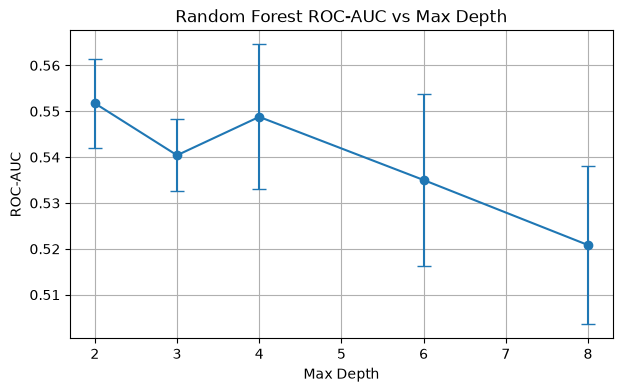

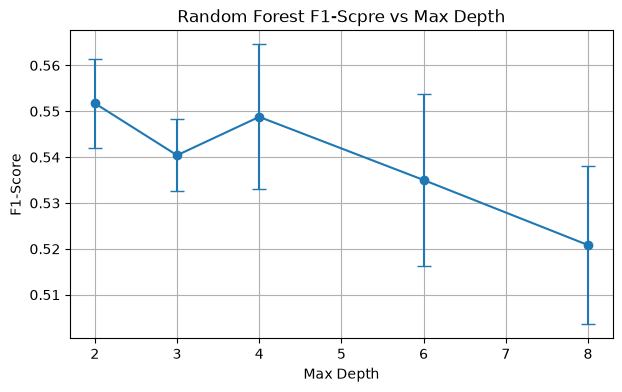

In [ ]:

n_estimators_list = [5, 10, 25, 50]
max_depths = [2, 3, 4, 6, 8]
min_sample_leafs = [4, 8]
#max_features = [0.6, 0.7, 0.8]
max_features = [0.7]

results = []

df_encoded = pd.get_dummies(df_ml_ready.copy(), columns=['gender', 'fever_muscle_pain', 'respiratory_condition'], drop_first=True)
X = df_encoded.drop(columns=['diagnosis'], errors='ignore')
y = (df_encoded['diagnosis'] == 'COVID-19').astype(int)

for n_trees in n_estimators_list:
    for max_depth in max_depths:
        for min_samples_leaf in min_sample_leafs:
            for max_feature in max_features:
                result, feature_importance = run_random_forest(X, y, False, n_trees, max_depth, min_samples_leaf, max_feature)
                results.append({
                    #"accuracy": result.get("accuracy"),
                    "f1_score": result.get("f1_score"),
                    "roc_auc": result.get("roc_auc"),
                    "specificity": result.get("specificity"),
                    "sensitivity": result.get("sensitivity"),
                    "n_estimators": n_trees,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "max_feature": max_feature
                })  
results_df = pd.DataFrame(results)
print(results_df)

depth_stats_auc = (
    results_df.groupby("max_depth")["roc_auc"]
    .agg(["mean", "std"])
    .reset_index()
)
plt.figure(figsize=(7, 4))
plt.errorbar(
    depth_stats_auc["max_depth"],
    depth_stats_auc["mean"],
    yerr=depth_stats_auc["std"],
    marker="o",
    capsize=5
)
plt.xlabel("Max Depth")
plt.ylabel("ROC-AUC")
plt.title("Random Forest ROC-AUC vs Max Depth")
plt.grid(True)
plt.show()

depth_stats_f1 = (
    results_df.groupby("max_depth")["f1_score"]
    .agg(["mean", "std"])
    .reset_index()
)
plt.figure(figsize=(7, 4))
plt.errorbar(
    depth_stats_auc["max_depth"],
    depth_stats_auc["mean"],
    yerr=depth_stats_auc["std"],
    marker="o",
    capsize=5
)
plt.xlabel("Max Depth")
plt.ylabel("F1-Score")
plt.title("Random Forest F1-Scpre vs Max Depth")
plt.grid(True)

plt.show()

The best run for random forest had f1_score of 0.304 and roc_auc of 0.575. Parameters are n_estimators=10, max_depth=4, min_samples_leaf=4 and max_feature=0.7

This means the trees are kept shallow. Increasing parameters like max_depth or min_samples_leaf would allow the model to capture more complex relationships. Yet this leads to reduced test performance which might indicate that there is probably too much noise lef tin the features/ preprocessed data like background sounds or poorly extracted audio features in general.

#### SVM

In [40]:
df_encoded = pd.get_dummies(df_ml_ready.copy(), columns=['gender', 'fever_muscle_pain', 'respiratory_condition'], drop_first=True)
X = df_encoded.drop(columns=['diagnosis'], errors='ignore')
y = (df_encoded['diagnosis'] == 'COVID-19').astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# 1. Scale data (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train SVM
svm_model = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
# 3. Predictions
y_pred = svm_model.predict(X_test_scaled)
y_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
# 4. Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
print("--- SVM RESULTS ---")
print(f"Accuracy: {accuracy:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

--- SVM RESULTS ---
Accuracy: 0.590
F1-score: 0.271
ROC-AUC: 0.513


simple SVM run showed that its not only Random forest that fails to identify COVID-19 positive cases. THis enforces my previous point about how unreliable/ noisy either my extracted features or the general coughvid-database itself is.

### Unsupervised ML

#### K-means

In [41]:
# Select only the engineered numeric audio features 
X_unlabelled = df_features_cleaned.select_dtypes(include=[np.number]).copy()

# Drop any administrative or label columns if they got caught in select_dtypes
X_unlabelled = X_unlabelled.drop(columns=['diagnosis'], errors='ignore')

# Scale the features meticulously
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unlabelled)

# Evaluate internal cluster fitness for different values of k
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Calculate Silhouette Score (Closer to 1 means clean, isolated clusters)
    sil_avg = silhouette_score(X_scaled, cluster_labels)
    print(f"For k={k} | Cluster Inertia: {kmeans.inertia_:.2f} | Silhouette Score: {sil_avg:.3f}")

# Run the formal k=2 clustering
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
final_clusters = kmeans_final.fit_predict(X_scaled)

# Create a validation dataframe combining Ground Truth and Cluster ID
df_validation = pd.DataFrame({
    'Ground_Truth': (df_features_cleaned['diagnosis'] == 'COVID-19').astype(int).values,
    'KMeans_Cluster': final_clusters
})

# Generate a Contingency Matrix (Cross-tabulation)
contingency_matrix = pd.crosstab(df_validation['Ground_Truth'], df_validation['KMeans_Cluster'])
print("\n=== Contingency Matrix ===")
print(contingency_matrix)

# Calculate Adjusted Rand Index (ARI) 
# Scores close to 0 mean the clusters are essentially randomly split relative to the labels
ari_score = adjusted_rand_score(df_validation['Ground_Truth'], df_validation['KMeans_Cluster'])
print(f"\nAdjusted Rand Index (ARI): {ari_score:.4f}")

For k=2 | Cluster Inertia: 109613.94 | Silhouette Score: 0.104
For k=3 | Cluster Inertia: 104470.03 | Silhouette Score: 0.081
For k=4 | Cluster Inertia: 100445.21 | Silhouette Score: 0.062
For k=5 | Cluster Inertia: 97759.31 | Silhouette Score: 0.060

=== Contingency Matrix ===
KMeans_Cluster     0     1
Ground_Truth              
0               1044  1160
1                217   334

Adjusted Rand Index (ARI): -0.0028


In [42]:
def run_internal_evaluation(X_scaled, cluster_labels):
    """
    Generates a professional Silhouette Plot to assess cluster separation
    without using ground truth labels (Task 4b).
    """
    # Calculate global average silhouette score
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    
    # Compute the silhouette scores for each individual sample
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)
    
    # Setup the plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # The silhouette coefficient can range from -1, 1 but usually -0.2 to 1 is enough
    ax.set_xlim([-0.2, 1])
    ax.set_ylim([0, len(X_scaled) + (len(np.unique(cluster_labels)) + 1) * 10])
    
    y_lower = 10
    n_clusters = len(np.unique(cluster_labels))
    
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        # Color mapping similar to the professor's slides (e.g., paired colors)
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        
        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        
        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples
        
    ax.set_title("Silhouette Plot for Clustering Fitness", fontsize=14, fontweight='bold')
    ax.set_xlabel("Silhouette Coefficient Values", fontsize=12)
    ax.set_ylabel("Cluster Label", fontsize=12)
    
    # The vertical line for average silhouette score of all the values
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    
    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xticks(np.arange(-0.2, 1.2, 0.2))
    
    print(f"Average Silhouette Width: {silhouette_avg:.3f}")
    plt.tight_layout()
    plt.show()

In [43]:
def run_external_evaluation(df_validation):
    """
    Calculates external clustering metrics using ground truth labels 
    and plots them as a horizontal bar chart (Task 4a).
    """
    # Extract the true labels and predicted clusters
    y_true = df_validation['Ground_Truth']
    y_pred = df_validation['KMeans_Cluster']
    
    # Calculate all required metrics
    metrics_dict = {
        'ARI': adjusted_rand_score(y_true, y_pred),
        'Homogeneity': homogeneity_score(y_true, y_pred),
        'V-Measure': v_measure_score(y_true, y_pred),
        'Completeness': completeness_score(y_true, y_pred),
        'NMI': normalized_mutual_info_score(y_true, y_pred)
    }
    
    # Print the raw values for your thesis text
    print("=== External Evaluation Metrics ===")
    for name, score in metrics_dict.items():
        print(f"{name}: {score:.3f}")
        
    # Setup the Bar Chart
    names = list(metrics_dict.keys())
    scores = list(metrics_dict.values())
    
    fig, ax = plt.subplots(figsize=(6, 8))
    
    # Create horizontal bars (reversing order so ARI is at the top like the slide)
    y_pos = np.arange(len(names))
    ax.barh(y_pos, scores[::-1], color='#E68453', edgecolor='white', height=0.6)
    
    # Add text labels inside the bars
    for i, v in enumerate(scores[::-1]):
        ax.text(v + 0.02, i, f"{v:.3f}", color='black', va='center', fontweight='bold')
    
    # Formatting to match the professor's style
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names[::-1])
    ax.set_xlim(0, 1.0) # Metrics range from 0 to 1
    ax.set_xlabel("Score [0 - 1, higher is better]")
    ax.set_title("External Evaluation Metrics (k=2 vs Ground Truth)", fontsize=12, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Remove top and right spines for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

--- Running Internal Evaluation ---
Average Silhouette Width: 0.104


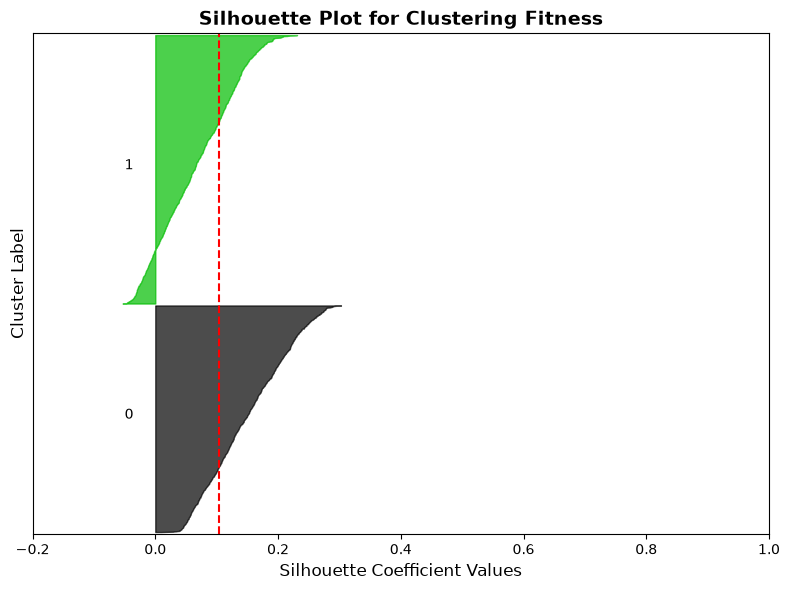


--- Running External Evaluation ---
=== External Evaluation Metrics ===
ARI: -0.003
Homogeneity: 0.004
V-Measure: 0.003
Completeness: 0.003
NMI: 0.003


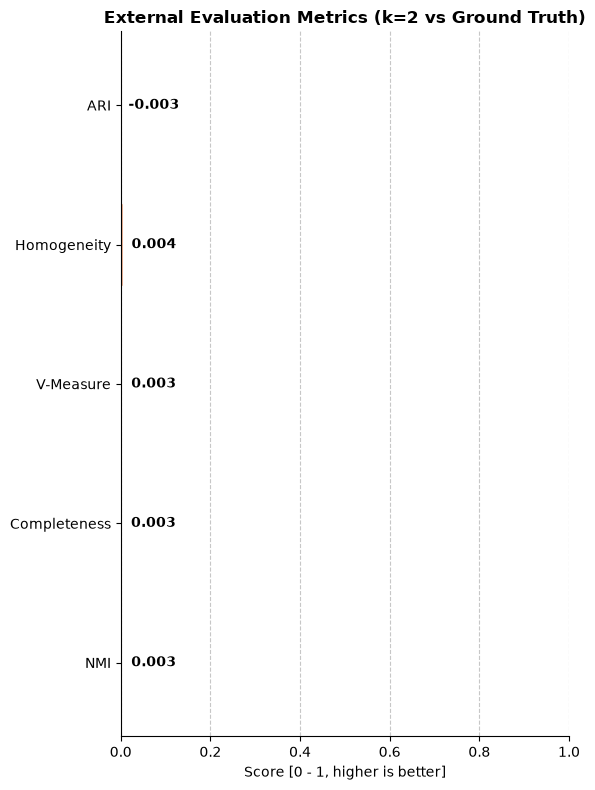

In [44]:
# Assuming X_scaled and final_clusters are already calculated from your k-means step
print("--- Running Internal Evaluation ---")
run_internal_evaluation(X_scaled, final_clusters)

# Assuming df_validation is created (with the .values fix!)
print("\n--- Running External Evaluation ---")
run_external_evaluation(df_validation)

THe silhouette score of 0.1 shows that the cough features do not form two separate geometric groups but instead onw 'cloud' of noise. K-means struggles to split COVID-positive and COVID-negative datapoints as both overlap immensely and bleed into each other.

ARI measures the similarity between cluster assignment and true daignosis. A score of around/below 0 means that its pure noise and so similarities. Homogenity means that each cluste ronly contain one class, a score towards 0 means that both clusters have the same amount of COVID-positive and negative datapoints. Completeness describes whether all members of a class were assigned to the same cluster. A value close to 0 means that they are completely scattered randomly. V-Measure & NMI combine homogenity & completeness. low value = knowing which cluster a datapoint belongs to gives the mdoel zero knowledge about its diagnosis.

#### Autoencoder

In [ ]:
# Drop administrative/label columns to isolate numeric audio features
X = df_features_cleaned.select_dtypes(include=[np.number]).copy()
X = X.drop(columns=['diagnosis'], errors='ignore')
y = (df_features_cleaned['diagnosis'] == 'COVID-19').astype(int).values

# Split into train and test sets immediately to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features based on the training data distribution
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]
latent_dim = 8  # Squeezing the features down into 8 dense dimensions

print(f"Original Feature Shape: {input_dim}")
print(f"Target Latent Space Shape: {latent_dim}\n")

# Input layer
input_layer = Input(shape=(input_dim,), name="Handcrafted_Features_Input")
# Encoder Layers (Compressing)
encoder_hidden = Dense(32, activation='relu', name="Encoder_Hidden")(input_layer)
bottleneck = Dense(latent_dim, activation='relu', name="Latent_Space_Bottleneck")(encoder_hidden)
# Decoder Layers (Reconstructing)
decoder_hidden = Dense(32, activation='relu', name="Decoder_Hidden")(bottleneck)
# CRUCIAL: Output layer uses 'linear' activation because scaled input data contains negative values
output_layer = Dense(input_dim, activation='linear', name="Reconstructed_Output")(decoder_hidden)
# Define the complete Autoencoder Model
autoencoder = Model(inputs=input_layer, outputs=output_layer, name="Complete_Autoencoder")
autoencoder.compile(optimizer='adam', loss='mse')

#train autoencoder
print("=== Training the Autoencoder ===")
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,      # Target is the input itself (unsupervised)
    epochs=60,
    batch_size=32,
    validation_split=0.1,                # Use 10% of training data to check convergence
    verbose=1
)

# Create a standalone Encoder model that stops at the bottleneck layer
encoder_model = Model(inputs=input_layer, outputs=bottleneck, name="Feature_Extractor_Encoder")
# Transform your original scaled matrices into compressed deep features
X_train_encoded = encoder_model.predict(X_train_scaled)
X_test_encoded = encoder_model.predict(X_test_scaled)

print(f"\nNew Compressed Training Shape: {X_train_encoded.shape}")
print(f"New Compressed Testing Shape: {X_test_encoded.shape}\n")

# Define the exact same architectures used in your previous baseline tasks
lr_latent = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rf_latent = RandomForestClassifier(n_estimators=10, max_depth=4, min_samples_leaf=4, class_weight="balanced_subsample", random_state=42)

# Fit Logistic Regression on encoded features
lr_latent.fit(X_train_encoded, y_train)
lr_preds = lr_latent.predict(X_test_encoded)
lr_probs = lr_latent.predict_proba(X_test_encoded)[:, 1]

# Fit Random Forest on encoded features
rf_latent.fit(X_train_encoded, y_train)
rf_preds = rf_latent.predict(X_test_encoded)
rf_probs = rf_latent.predict_proba(X_test_encoded)[:, 1]

# =====================================================================
# STEP 6: GENERATE COMPARISON REPORT (TASK 5b)
# =====================================================================
# Replace the "Original" column values below with your exact baseline notebook metrics
comparison_data = {
    "Model Configuration": [
        "Logistic Regression (Original Features)",
        "Logistic Regression (Autoencoder Latent Space)",
        "Random Forest (Original Features)",
        "Random Forest (Autoencoder Latent Space)"
    ],
    "Accuracy": [
        0.574, 
        accuracy_score(y_test, lr_preds),
        0.560, 
        accuracy_score(y_test, rf_preds)
    ],
    "F1-Score": [
        0.311,
        f1_score(y_test, lr_preds),
        0.304,
        f1_score(y_test, rf_preds)
    ],
    "ROC-AUC": [
        0.545,
        roc_auc_score(y_test, lr_probs),
        0.575,
        roc_auc_score(y_test, rf_probs)
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("=== FINAL TASK 5 COMPARISON REPORT ===")
print(df_comparison.to_string(index=False))

Original Feature Shape: 45
Target Latent Space Shape: 8

=== Training the Autoencoder ===
Epoch 1/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.9987 - val_loss: 1.0300
Epoch 2/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8894 - val_loss: 0.8566
Epoch 3/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7483 - val_loss: 0.7530
Epoch 4/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6798 - val_loss: 0.6983
Epoch 5/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6342 - val_loss: 0.6542
Epoch 6/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5963 - val_loss: 0.6196
Epoch 7/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5617 - val_loss: 0.5945
Epoch 8/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5370 - val_loss: 0.5732
Epoch 9/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5168 - val_loss: 0.5602
Epoch 10/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5025 - val_loss: 0.5482
Epoch 11/60
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4913 - v